# Pokémon analytics notebook
High-level EDA and modeling across two Kaggle datasets. Outputs are saved under `output/` and integrated into the paper and slides.


In [60]:
import kagglehub

path = kagglehub.dataset_download("hamzacyberpatcher/data-of-1010-pokemons")

print("Path to dataset files:", path)

Path to dataset files: /Users/wesgr/.cache/kagglehub/datasets/hamzacyberpatcher/data-of-1010-pokemons/versions/5


In [61]:
# Utilities for rich display in notebook outputs
from IPython.display import display


In [62]:
from pathlib import Path

# Locate dataset directory from previous cell's `path`, or download if needed
try:
    dataset_root = Path(path)
except NameError:  # fallback if cell above hasn't been run yet
    import kagglehub
    dataset_root = Path(kagglehub.dataset_download("hamzacyberpatcher/data-of-1010-pokemons"))

available_files = sorted([p for p in dataset_root.rglob("*") if p.is_file()])

print(f"Dataset directory: {dataset_root}")
print("Available files (top 10):")
for p in available_files[:10]:
    print("-", p.relative_to(dataset_root))

# Pick a likely tabular dataset file (prefer CSV, then XLSX)
preferred_extensions = [".csv", ".xlsx"]
candidate_files = [p for p in available_files if p.suffix.lower() in preferred_extensions]

if not candidate_files:
    raise FileNotFoundError("No CSV or XLSX files found in the dataset directory.")

dataset_file = candidate_files[0]
print("Selected dataset file:", dataset_file.name)


Dataset directory: /Users/wesgr/.cache/kagglehub/datasets/hamzacyberpatcher/data-of-1010-pokemons/versions/5
Available files (top 10):
- pokemons.csv
Selected dataset file: pokemons.csv


In [63]:
import pandas as pd

# Load the selected adataset file and inspect its structure
suffix = dataset_file.suffix.lower()
if suffix == ".csv":
    df = pd.read_csv(dataset_file)
elif suffix in {".xls", ".xlsx"}:
    df = pd.read_excel(dataset_file)
else:
    raise ValueError(f"Unsupported file type: {suffix}")

print("Shape:", df.shape)
print("\nColumns:")
print(list(df.columns))

print("\nHead:")
display(df.head())


Shape: (1025, 18)

Columns:
['id', 'name', 'rank', 'generation', 'evolves_from', 'type1', 'type2', 'hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'total', 'height', 'weight', 'abilities', 'desc']

Head:


,id,name,rank,generation,evolves_from,type1,type2,hp,atk,def,spatk,spdef,speed,total,height,weight,abilities,desc
0,1,bulbasaur,ordinary,generation-i,nothing,grass,poison,45,49,49,65,65,45,318,7,69,overgrow chlorophyll,A strange seed was planted on its back at birt...
1,2,ivysaur,ordinary,generation-i,bulbasaur,grass,poison,60,62,63,80,80,60,405,10,130,overgrow chlorophyll,"When the bulb on its back grows large, it appe..."
2,3,venusaur,ordinary,generation-i,ivysaur,grass,poison,80,82,83,100,100,80,525,20,1000,overgrow chlorophyll,The plant blooms when it is absorbing solar en...
3,4,charmander,ordinary,generation-i,nothing,fire,NaN,39,52,43,60,50,65,309,6,85,blaze solar-power,"Obviously prefers hot places. When it rains, s..."
4,5,charmeleon,ordinary,generation-i,charmander,fire,NaN,58,64,58,80,65,80,405,11,190,blaze solar-power,"When it swings its burning tail, it elevates t..."


## Dataset A: loading, profiling, and cleaning
Download via `kagglehub`, locate the main table, inspect schema, profile missingness/duplicates, and standardize fields (generation parsing, legendary flags, type handling). Creates `df_clean` for downstream use.


In [64]:
# Quick structure profile: dtypes, missingness, duplicates
print("Shape:", df.shape)

print("\nDataFrame info:")
df.info()

print("\nMissing values per column (non-zero):")
na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
display(na_counts)

duplicate_rows = df.duplicated().sum()
duplicate_ids = df['id'].duplicated().sum() if 'id' in df.columns else None
print(f"\nDuplicate rows: {duplicate_rows}")
if duplicate_ids is not None:
    print(f"Duplicate ids: {duplicate_ids}")


Shape: (1025, 18)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1025 non-null   int64 
 1   name          1025 non-null   object
 2   rank          1025 non-null   object
 3   generation    1025 non-null   object
 4   evolves_from  1025 non-null   object
 5   type1         1025 non-null   object
 6   type2         526 non-null    object
 7   hp            1025 non-null   int64 
 8   atk           1025 non-null   int64 
 9   def           1025 non-null   int64 
 10  spatk         1025 non-null   int64 
 11  spdef         1025 non-null   int64 
 12  speed         1025 non-null   int64 
 13  total         1025 non-null   int64 
 14  height        1025 non-null   int64 
 15  weight        1025 non-null   int64 
 16  abilities     1025 non-null   object
 17  desc          1025 non-null   object
dtypes: int64(10),

type2    499
dtype: int64


Duplicate rows: 0
Duplicate ids: 0


In [65]:
# Descriptive statistics for numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns
print("Numeric columns:", list(numeric_cols))

display(df[numeric_cols].describe().T)

# Quick look at categorical columns cardinality
categorical_cols = df.select_dtypes(include=["object", "category"]).columns
cardinality = df[categorical_cols].nunique().sort_values(ascending=False)
print("\nCategorical columns and their unique counts (top 15):")
display(cardinality.head(15))


Numeric columns: ['id', 'hp', 'atk', 'def', 'spatk', 'spdef', 'speed', 'total', 'height', 'weight']


,count,mean,std,min,25%,50%,75%,max
id,1025.0,513.000000,296.036315,1.0,257.0,513.0,769.0,1025.0
hp,1025.0,70.184390,26.631054,1.0,50.0,68.0,85.0,255.0
atk,1025.0,77.521951,29.782541,5.0,55.0,75.0,100.0,181.0
def,1025.0,72.507317,29.286972,5.0,50.0,70.0,90.0,230.0
spatk,1025.0,70.080976,29.658378,10.0,47.0,65.0,90.0,173.0
spdef,1025.0,70.205854,26.639329,20.0,50.0,67.0,86.0,230.0
speed,1025.0,67.186341,28.717227,5.0,45.0,65.0,88.0,200.0
total,1025.0,427.686829,112.770735,175.0,325.0,450.0,508.0,720.0
height,1025.0,12.116098,12.481673,1.0,5.0,10.0,15.0,200.0
weight,1025.0,669.865366,1212.731138,1.0,85.0,280.0,700.0,9999.0



Categorical columns and their unique counts (top 15):


name            1025
desc            1009
abilities        623
evolves_from     458
type1             18
type2             18
generation         9
rank               4
dtype: int64

In [66]:
# Data hygiene: create cleaned DataFrame with helpful standardized fields
import numpy as np

df_clean = df.copy()

# Standardize 'evolves_from': replace 'nothing' (case-insensitive) with NaN
if 'evolves_from' in df_clean.columns:
    df_clean['evolves_from'] = (
        df_clean['evolves_from']
        .astype(str)
        .str.strip()
        .replace({"nothing": np.nan, "Nothing": np.nan, "NONE": np.nan})
    )

# Ensure generation numeric column extracted from strings like 'generation-i'
roman_to_int = {
    "i": 1, "ii": 2, "iii": 3, "iv": 4, "v": 5,
    "vi": 6, "vii": 7, "viii": 8, "ix": 9
}

def extract_generation_num(value: str) -> float:
    if not isinstance(value, str):
        return np.nan
    value = value.strip().lower()
    # Expected format 'generation-<roman>'
    if value.startswith("generation-"):
        roman = value.split("-", 1)[1]
        return roman_to_int.get(roman, np.nan)
    # Fallback: try exact roman
    return roman_to_int.get(value, np.nan)

if 'generation' in df_clean.columns:
    df_clean['generation_num'] = df_clean['generation'].apply(extract_generation_num).astype('Int64')

# Boolean flags to support analyses
if 'rank' in df_clean.columns:
    df_clean['rank'] = df_clean['rank'].astype(str).str.strip().str.lower()
    df_clean['is_legendary'] = df_clean['rank'].isin(["legendary", "mythical"])  # treat mythical as legendary cohort
    df_clean['is_baby'] = df_clean['rank'].eq("baby")

# Helper field for counting secondary types (keep original 'type2' intact)
if 'type2' in df_clean.columns:
    df_clean['type2_filled'] = df_clean['type2'].fillna('none')

# Optionally cast common categoricals
for col in ["rank", "generation", "type1", "type2", "type2_filled"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

print("df_clean created. Columns added:")
new_cols = [c for c in ["generation_num", "is_legendary", "is_baby", "type2_filled"] if c in df_clean.columns]
print(new_cols)

print("\nMissing values after standardization (selected columns):")
selected = [c for c in ["evolves_from", "type2", "type2_filled"] if c in df_clean.columns]
display(df_clean[selected].isna().sum())

print("\n'type2_filled' value counts (top 10):")
display(df_clean['type2_filled'].value_counts().head(10))


df_clean created. Columns added:
['generation_num', 'is_legendary', 'is_baby', 'type2_filled']

Missing values after standardization (selected columns):


evolves_from    541
type2           499
type2_filled      0
dtype: int64


'type2_filled' value counts (top 10):


type2_filled
none        499
flying      100
psychic      42
poison       41
fairy        35
ground       35
dragon       33
fighting     33
ghost        30
steel        29
Name: count, dtype: int64

## Dataset A: core analyses and visualizations
Counts by generation and type, correlation of base stats, legendary vs non-legendary comparisons, feature engineering for indices, PCA projection, and role-tag exploration.


Generation counts:


,count
generation_num,
1,151
2,100
3,135
4,107
5,156
6,72
7,88
8,96
9,120



Primary type counts (top 20):


,count
type1,
water,134
normal,118
grass,103
bug,83
fire,66
psychic,60
electric,59
rock,58
dark,45



Secondary type counts (top 20, excluding None):


,count
type2,
flying,100
psychic,42
poison,41
fairy,35
ground,35
dragon,33
fighting,33
ghost,30
steel,29


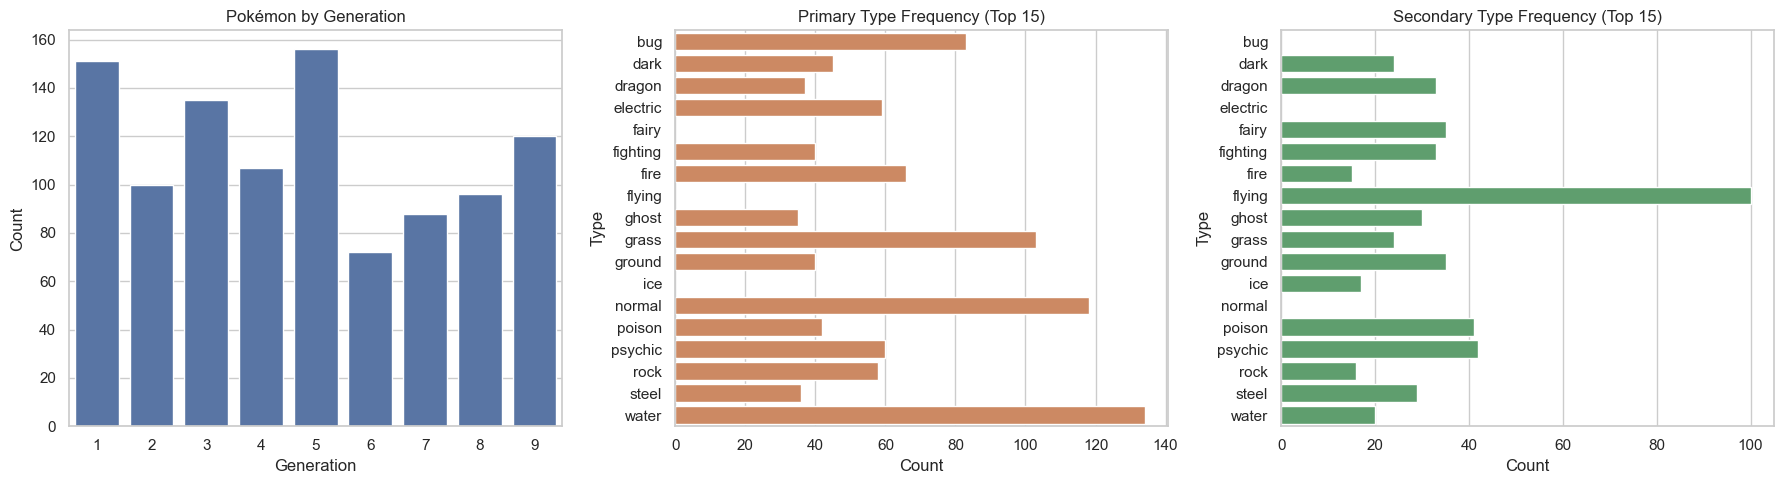

In [67]:
# Counts by generation and type (primary/secondary) with visuals
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Counts
gen_counts = df_clean['generation_num'].value_counts().sort_index()
type1_counts = df_clean['type1'].value_counts().sort_values(ascending=False)
type2_counts = df_clean.loc[df_clean['type2'].notna(), 'type2'].value_counts().sort_values(ascending=False)

print("Generation counts:")
display(gen_counts.to_frame("count"))

print("\nPrimary type counts (top 20):")
display(type1_counts.head(20).to_frame("count"))

print("\nSecondary type counts (top 20, excluding None):")
display(type2_counts.head(20).to_frame("count"))

# Visuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generation bar plot
sns.barplot(x=gen_counts.index.astype("int"), y=gen_counts.values, ax=axes[0], color="C0")
axes[0].set_title("Pokémon by Generation")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Count")

# Primary type horizontal bar plot (top 15)
plot_n = 15
sns.barplot(y=type1_counts.index[:plot_n], x=type1_counts.values[:plot_n], ax=axes[1], color="C1")
axes[1].set_title("Primary Type Frequency (Top 15)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Type")

# Secondary type horizontal bar plot (top 15)
sns.barplot(y=type2_counts.index[:plot_n], x=type2_counts.values[:plot_n], ax=axes[2], color="C2")
axes[2].set_title("Secondary Type Frequency (Top 15)")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Type")

plt.tight_layout()
plt.show()


Key correlations (|r| >= 0.7):
atk vs total: r=0.714
spatk vs total: r=0.701


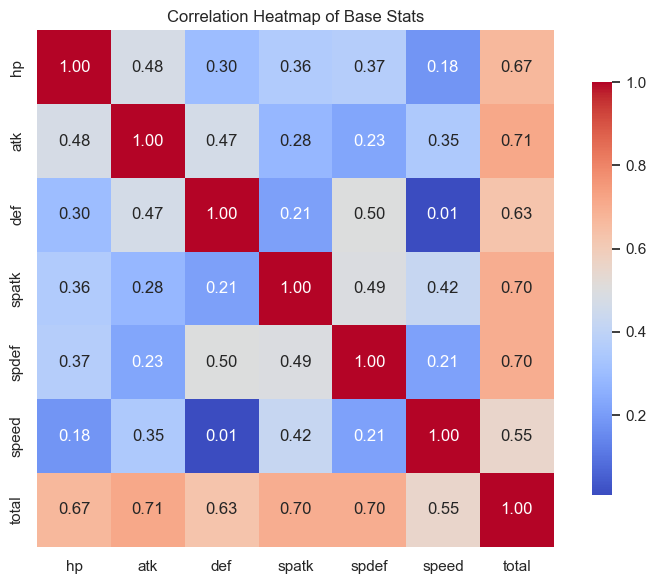

In [68]:
# Correlation heatmap of numerical stats
num_cols = ["hp", "atk", "def", "spatk", "spdef", "speed", "total"]

missing_cols = [c for c in num_cols if c not in df_clean.columns]
if missing_cols:
    raise KeyError(f"Missing expected numeric columns: {missing_cols}")

corr = df_clean[num_cols].corr(method='pearson')

# Print key correlations
print("Key correlations (|r| >= 0.7):")
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr.iloc[i,j]
        if abs(r) >= 0.7:
            print(f"{num_cols[i]} vs {num_cols[j]}: r={r:.3f}")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Base Stats")
plt.tight_layout()
plt.show()


Legendary vs Non-Legendary Analysis:
Sample sizes: Legendary/Mythical n=93, Non-Legendary n=932

Mean differences (Legendary - Non-Legendary):
hp: +25.7 (37.8% increase)
atk: +28.3 (37.7% increase)
def: +27.7 (39.6% increase)
spatk: +36.7 (55.1% increase)
spdef: +32.1 (47.7% increase)
speed: +30.8 (47.9% increase)
total: +181.3 (44.1% increase)


hp                                 atk         \
                         mean median        std count        mean median   
group                                                                      
Legendary/Mythical  93.516129   91.0  24.277209    93  103.247312  100.0   
Non-Legendary       67.856223   65.0  25.729585   932   74.954936   72.0   

                                           def         ...      spdef        \
                          std count       mean median  ...        std count   
group                                                  ...                    
Legendary/Mythical  25.461248    93  97.731183   95.0  ...  27.004744    93   
Non-Legendary       28.962699   932  69.990343   65.0  ...  24.800520   932   

                        speed                               total         \
                         mean median        std count        mean median   
group                                                                      
Legendary/Mythical  95.225806   97.0  27.993062    93  592.580645  600.0   
Non-Legendary       64.388412   62.0  27.262605   932  411.232833  425.0   

                                      
                           std count  
group                                 
Legendary/Mythical   77.163058    93  
Non-Legendary       102.039779   932  

[2 rows x 28 columns]

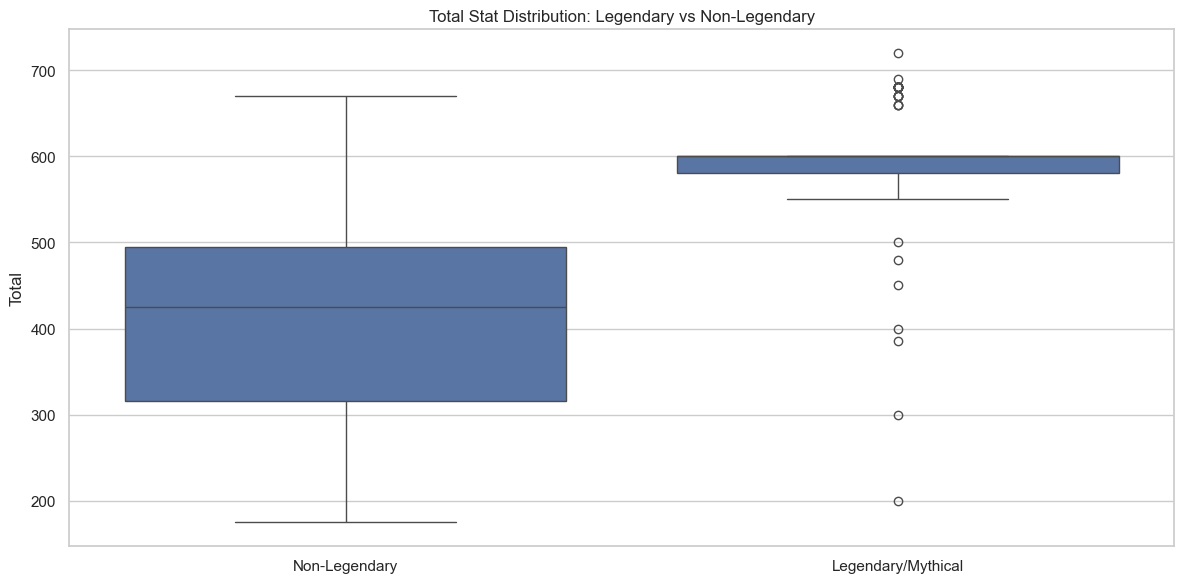


Statistical significance (Welch t-tests):
total: t=20.91, p=7.01e-43 ***
spatk: t=11.53, p=1.47e-20 ***
spdef: t=11.00, p=2.47e-19 ***
atk: t=10.08, p=1.36e-17 ***
speed: t=10.15, p=1.71e-17 ***
def: t=9.69, p=1.38e-16 ***
hp: t=9.67, p=1.72e-16 ***


,stat,t_stat,p_value
6,total,20.913103,7.007610e-43
3,spatk,11.525570,1.467863e-20
4,spdef,10.998822,2.469946e-19
1,atk,10.084668,1.359004e-17
5,speed,10.153878,1.708683e-17
2,def,9.689485,1.382912e-16
0,hp,9.665613,1.721367e-16


In [69]:
# Legendary vs Non-Legendary comparisons
from scipy import stats

legendary_df = df_clean[df_clean['is_legendary']]
nonlegendary_df = df_clean[~df_clean['is_legendary']]

print("Legendary vs Non-Legendary Analysis:")
print(f"Sample sizes: Legendary/Mythical n={len(legendary_df)}, Non-Legendary n={len(nonlegendary_df)}")

compare_cols = ["hp", "atk", "def", "spatk", "spdef", "speed", "total"]

summary = (
    df_clean.assign(group=np.where(df_clean['is_legendary'], 'Legendary/Mythical', 'Non-Legendary'))
    .groupby('group')[compare_cols]
    .agg(['mean', 'median', 'std', 'count'])
)

print("\nMean differences (Legendary - Non-Legendary):")
# Extract means directly from the multi-level DataFrame
for stat in compare_cols:
    leg_mean = summary.loc['Legendary/Mythical', (stat, 'mean')]
    non_mean = summary.loc['Non-Legendary', (stat, 'mean')]
    diff = leg_mean - non_mean
    pct_increase = (diff / non_mean) * 100
    print(f"{stat}: +{diff:.1f} ({pct_increase:.1f}% increase)")

display(summary)

# Visualize distributions with boxplots
plt.figure(figsize=(12, 6))
plot_df = df_clean.assign(group=np.where(df_clean['is_legendary'], 'Legendary/Mythical', 'Non-Legendary'))
plot_order = ['Non-Legendary', 'Legendary/Mythical']
sns.boxplot(data=plot_df, x='group', y='total', order=plot_order)
plt.title("Total Stat Distribution: Legendary vs Non-Legendary")
plt.xlabel("")
plt.ylabel("Total")
plt.tight_layout()
plt.show()

# Simple t-tests (Welch) for each stat
rows = []
for col in compare_cols:
    t, p = stats.ttest_ind(legendary_df[col], nonlegendary_df[col], equal_var=False, nan_policy='omit')
    rows.append({"stat": col, "t_stat": t, "p_value": p})

import pandas as pd
results_df = pd.DataFrame(rows).sort_values('p_value')
print("\nStatistical significance (Welch t-tests):")
for _, row in results_df.iterrows():
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"{row['stat']}: t={row['t_stat']:.2f}, p={row['p_value']:.2e} {sig}")

display(results_df)


In [70]:
# Feature engineering: offense/defense indices, speed-to-power, era-normalized total
engineered_cols = []

# Offense/Defense indices
if {'atk', 'spatk'}.issubset(df_clean.columns):
    df_clean['offense_index'] = (df_clean['atk'] + df_clean['spatk']) / 2.0
    engineered_cols.append('offense_index')
if {'def', 'spdef'}.issubset(df_clean.columns):
    df_clean['defense_index'] = (df_clean['def'] + df_clean['spdef']) / 2.0
    engineered_cols.append('defense_index')

# Speed-to-power ratio
if {'speed', 'total'}.issubset(df_clean.columns):
    df_clean['speed_to_power'] = df_clean['speed'] / df_clean['total']
    engineered_cols.append('speed_to_power')

# Era index: z-score of total within each generation
if {'generation_num', 'total'}.issubset(df_clean.columns):
    group_means = df_clean.groupby('generation_num')['total'].transform('mean')
    group_stds = df_clean.groupby('generation_num')['total'].transform('std')
    df_clean['era_total_z'] = (df_clean['total'] - group_means) / group_stds.replace(0, np.nan)
    engineered_cols.append('era_total_z')

print("Engineered features added:", engineered_cols)
display(df_clean[['name', 'type1', 'generation', 'total'] + engineered_cols].head(10))


Engineered features added: ['offense_index', 'defense_index', 'speed_to_power', 'era_total_z']


,name,type1,generation,total,offense_index,defense_index,speed_to_power,era_total_z
0,bulbasaur,grass,generation-i,318,57.0,57.0,0.141509,-0.897544
1,ivysaur,grass,generation-i,405,71.0,71.5,0.148148,-0.026457
2,venusaur,grass,generation-i,525,91.0,91.5,0.152381,1.175042
3,charmander,fire,generation-i,309,56.0,46.5,0.210356,-0.987656
4,charmeleon,fire,generation-i,405,72.0,61.5,0.197531,-0.026457
5,charizard,fire,generation-i,534,96.5,81.5,0.187266,1.265155
6,squirtle,water,generation-i,314,49.0,64.5,0.136943,-0.937594
7,wartortle,water,generation-i,405,64.0,80.0,0.143210,-0.026457
8,blastoise,water,generation-i,530,84.0,102.5,0.147170,1.225105
9,caterpie,bug,generation-i,195,25.0,27.5,0.230769,-2.129081


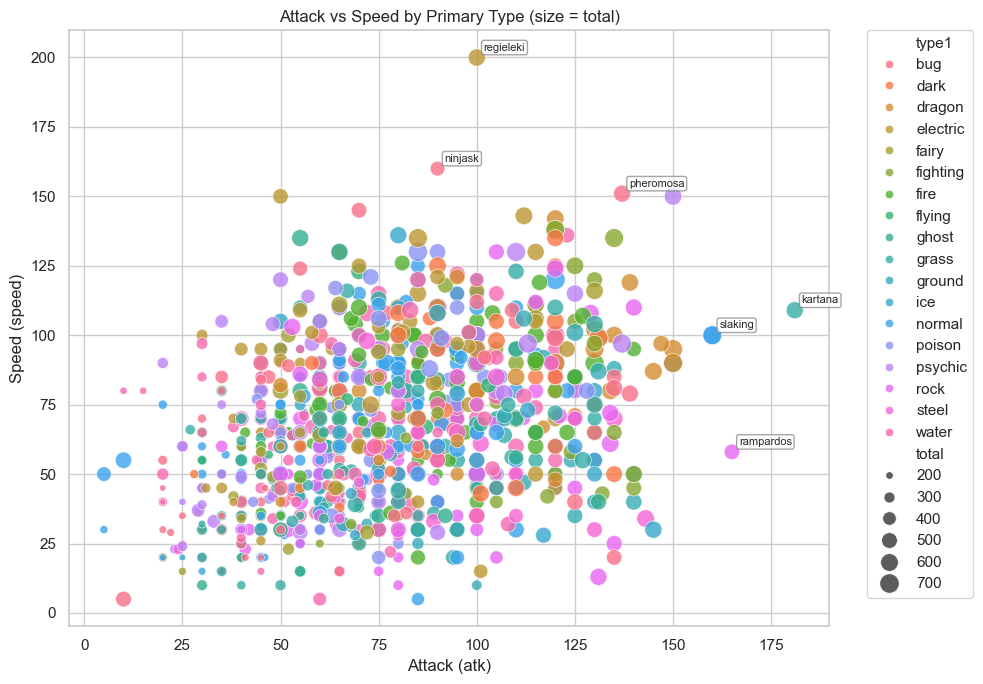

In [71]:
# Annotated scatter: Attack vs Speed, colored by type1, sized by total
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=df_clean,
    x='atk', y='speed', hue='type1', size='total', sizes=(20, 200),
    alpha=0.8, edgecolor='w', linewidth=0.5
)
plt.title("Attack vs Speed by Primary Type (size = total)")
plt.xlabel("Attack (atk)")
plt.ylabel("Speed (speed)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Annotate some interesting points: top speeders and attackers
annot_df = pd.concat([
    df_clean.nlargest(3, 'speed'),
    df_clean.nlargest(3, 'atk')
]).drop_duplicates(subset='id')

for _, row in annot_df.iterrows():
    plt.annotate(
        row['name'],
        (row['atk'], row['speed']),
        textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.7)
    )

plt.tight_layout()
plt.show()


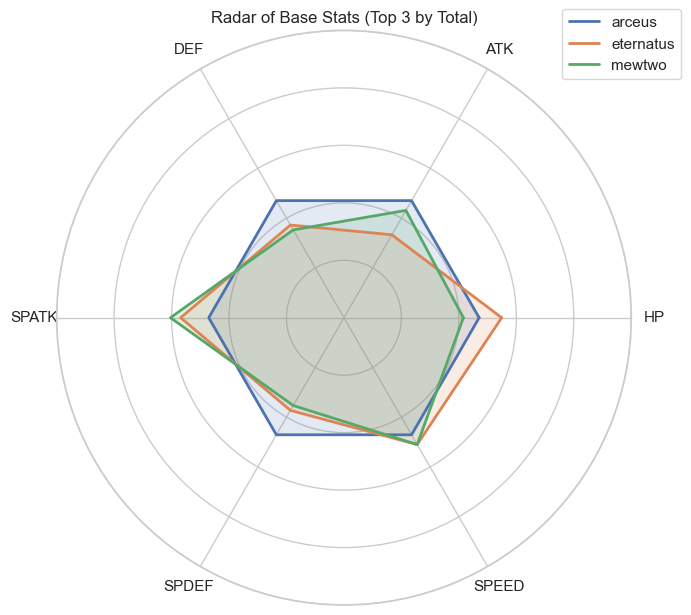

In [72]:
# Radar chart: compare base stats for top-total Pokémon
import numpy as np
import matplotlib.pyplot as plt

stats_axes = ["hp", "atk", "def", "spatk", "spdef", "speed"]

# Select top N by total for comparison
top_n = 3
sel = df_clean.nlargest(top_n, 'total')

labels = sel['name'].tolist()
values_mat = sel[stats_axes].to_numpy()

# Radar geometry
num_vars = len(stats_axes)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
angles = np.concatenate([angles, angles[:1]])  # close loop

# Normalize radial scale to a common max for readability (use 255 cap)
radial_max = 255.0
values_norm = values_mat / radial_max
values_norm = np.concatenate([values_norm, values_norm[:, :1]], axis=1)

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for row, label in zip(values_norm, labels):
    ax.plot(angles, row, linewidth=2, label=label)
    ax.fill(angles, row, alpha=0.15)

ax.set_xticks(np.linspace(0, 2 * np.pi, num_vars, endpoint=False))
ax.set_xticklabels([s.upper() for s in stats_axes])
ax.set_yticklabels([])
ax.set_ylim(0, 1)
plt.title(f"Radar of Base Stats (Top {top_n} by Total)")
plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.tight_layout()
plt.show()


In [73]:
# Output directory setup and save helper
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = Path('/Users/wesgr/Projects/School/AML/pokemon/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.0)


def savefig(filename: str, dpi: int = 300):
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f"Saved figure -> {path}")
    return path


In [74]:
# Additional feature engineering: BMI-like metric, bulkiness, offensive leaning, role tags
import numpy as np
import pandas as pd

# Height is in decimetres, weight in hectograms per dataset notes
# Approximate kg and meters for a BMI-like rough metric
kg = df_clean['weight'] / 10.0
m = df_clean['height'] / 10.0

df_clean['bmi_like'] = kg / (m.replace(0, np.nan) ** 2)

# Bulkiness: emphasize HP and defenses (simple product sqrt to keep scale reasonable)
df_clean['bulk_index'] = np.sqrt(np.clip(df_clean['hp'], 1, None) * np.clip(df_clean['def'], 1, None) * np.clip(df_clean['spdef'], 1, None))

# Offensive vs defensive leaning: normalized difference
num = (df_clean['offense_index'] - df_clean['defense_index'])
den = (df_clean['offense_index'] + df_clean['defense_index']).replace(0, np.nan)
df_clean['offense_bias'] = num / den

# Simple role tags based on thresholds
roles = []
for _, r in df_clean.iterrows():
    role = 'balanced'
    if r['speed'] >= 100 and r['offense_index'] >= 100:
        role = 'sweeper'
    elif r['bulk_index'] >= df_clean['bulk_index'].quantile(0.85) and r['defense_index'] >= 90:
        role = 'wall'
    elif r['offense_bias'] >= 0.2 and r['offense_index'] >= 90:
        role = 'attacker'
    elif r['offense_bias'] <= -0.2 and r['defense_index'] >= 90:
        role = 'tank'
    roles.append(role)

df_clean['role_tag'] = pd.Categorical(roles, categories=['sweeper','attacker','balanced','tank','wall'])

print("New engineered columns: ['bmi_like', 'bulk_index', 'offense_bias', 'role_tag']")
display(df_clean[['name','type1','generation','offense_index','defense_index','offense_bias','bulk_index','role_tag']].head(10))


New engineered columns: ['bmi_like', 'bulk_index', 'offense_bias', 'role_tag']


,name,type1,generation,offense_index,defense_index,offense_bias,bulk_index,role_tag
0,bulbasaur,grass,generation-i,57.0,57.0,0.000000,378.582884,balanced
1,ivysaur,grass,generation-i,71.0,71.5,-0.003509,549.909083,balanced
2,venusaur,grass,generation-i,91.0,91.5,-0.002740,814.861951,balanced
3,charmander,fire,generation-i,56.0,46.5,0.092683,289.568645,balanced
4,charmeleon,fire,generation-i,72.0,61.5,0.078652,467.610949,balanced
5,charizard,fire,generation-i,96.5,81.5,0.084270,719.124468,balanced
6,squirtle,water,generation-i,49.0,64.5,-0.136564,427.831743,balanced
7,wartortle,water,generation-i,64.0,80.0,-0.111111,614.491660,balanced
8,blastoise,water,generation-i,84.0,102.5,-0.099196,910.768906,wall
9,caterpie,bug,generation-i,25.0,27.5,-0.047619,177.482393,balanced


Power creep analysis - Mean total by generation:
Gen 1: 407.6 ± 15.9 (n=151)
Gen 2: 407.2 ± 22.0 (n=100)
Gen 3: 403.7 ± 19.5 (n=135)
Gen 4: 445.6 ± 22.2 (n=107)
Gen 5: 425.8 ± 16.1 (n=156)
Gen 6: 429.3 ± 25.8 (n=72)
Gen 7: 449.4 ± 24.9 (n=88)
Gen 8: 439.2 ± 23.3 (n=96)
Gen 9: 457.4 ± 20.9 (n=120)

Overall trend: 53.7 point increase over 8 generations
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/power_creep_mean_ci.png


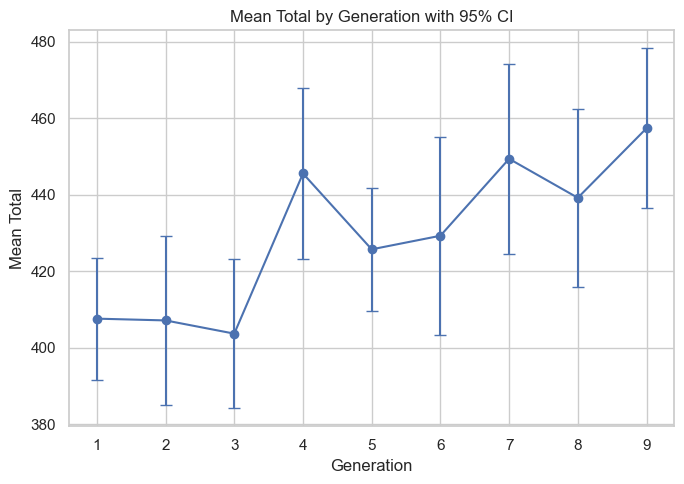

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/power_creep_violin.png


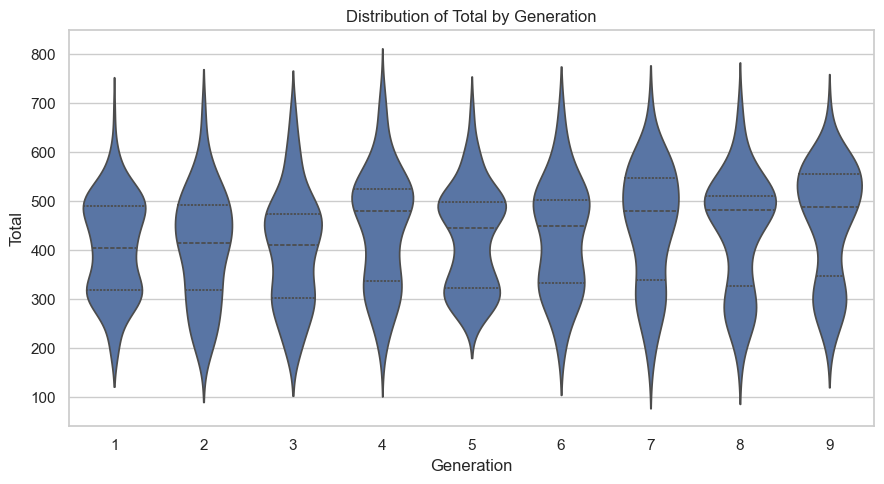

In [75]:
# Power creep analysis: generation-wise total stats (mean+CI and distribution)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mean and 95% CI per generation
agg = (
    df_clean.groupby('generation_num')['total']
    .agg(['count', 'mean', 'std'])
    .reset_index()
    .rename(columns={'count': 'n'})
)
agg['se'] = agg['std'] / np.sqrt(agg['n'])
agg['ci95'] = 1.96 * agg['se']

print("Power creep analysis - Mean total by generation:")
for _, row in agg.iterrows():
    print(f"Gen {int(row['generation_num'])}: {row['mean']:.1f} ± {row['ci95']:.1f} (n={int(row['n'])})")

# Check for trend
gen_range = agg['generation_num'].max() - agg['generation_num'].min()
mean_change = agg['mean'].max() - agg['mean'].min()
print(f"\nOverall trend: {mean_change:.1f} point increase over {int(gen_range)} generations")

plt.figure(figsize=(7,5))
plt.errorbar(agg['generation_num'], agg['mean'], yerr=agg['ci95'], fmt='-o', capsize=4)
plt.title('Mean Total by Generation with 95% CI')
plt.xlabel('Generation')
plt.ylabel('Mean Total')
plt.xticks(agg['generation_num'])
plt.tight_layout()
savefig('power_creep_mean_ci.png')
plt.show()

# Distribution per generation (violin)
plt.figure(figsize=(9,5))
sns.violinplot(data=df_clean, x='generation_num', y='total', inner='quartile')
plt.title('Distribution of Total by Generation')
plt.xlabel('Generation')
plt.ylabel('Total')
plt.tight_layout()
savefig('power_creep_violin.png')
plt.show()


Type centroids - Offense vs Defense positioning:
Top 5 offensive types:
dragon: offense=88.7, defense=76.5
fire: offense=82.9, defense=68.2
dark: offense=80.5, defense=71.2
steel: offense=79.9, defense=93.2
electric: offense=78.9, defense=64.3

Top 5 defensive types:
steel: defense=93.2, offense=79.9
rock: defense=85.6, offense=73.5
fairy: defense=78.4, offense=71.5
ghost: defense=78.2, offense=76.4
dragon: defense=76.5, offense=88.7

Overall averages: offense=73.8, defense=71.4
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/type_centroids_off_vs_def.png


/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/3073869143.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('type1')[['offense_index','defense_index']]


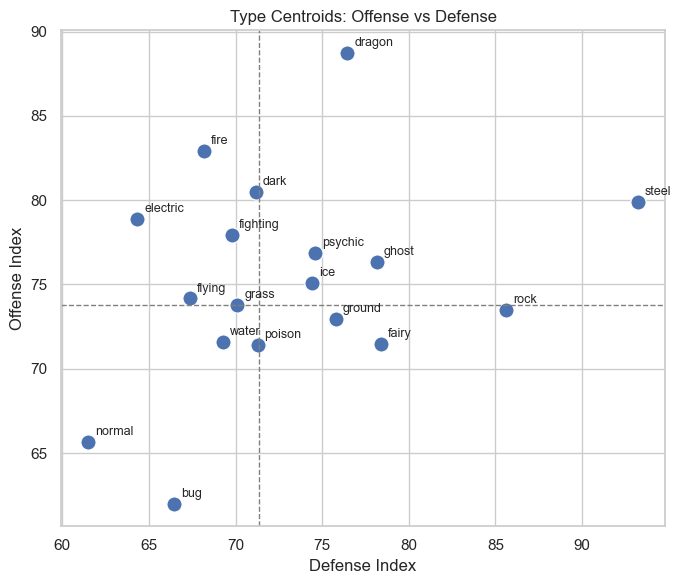

In [76]:
# Offense vs Defense centroids by primary type
centroids = (
    df_clean.groupby('type1')[['offense_index','defense_index']]
    .mean()
    .reset_index()
    .sort_values('offense_index', ascending=False)
)

print("Type centroids - Offense vs Defense positioning:")
print("Top 5 offensive types:")
for _, row in centroids.head(5).iterrows():
    print(f"{row['type1']}: offense={row['offense_index']:.1f}, defense={row['defense_index']:.1f}")

print("\nTop 5 defensive types:")
def_sorted = centroids.sort_values('defense_index', ascending=False)
for _, row in def_sorted.head(5).iterrows():
    print(f"{row['type1']}: defense={row['defense_index']:.1f}, offense={row['offense_index']:.1f}")

overall_off = df_clean['offense_index'].mean()
overall_def = df_clean['defense_index'].mean()
print(f"\nOverall averages: offense={overall_off:.1f}, defense={overall_def:.1f}")

plt.figure(figsize=(7,6))
sns.scatterplot(data=centroids, x='defense_index', y='offense_index', s=120)

for _, r in centroids.iterrows():
    plt.annotate(r['type1'], (r['defense_index'], r['offense_index']),
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

plt.axhline(overall_off, color='gray', lw=1, ls='--')
plt.axvline(overall_def, color='gray', lw=1, ls='--')
plt.title('Type Centroids: Offense vs Defense')
plt.xlabel('Defense Index')
plt.ylabel('Offense Index')
plt.tight_layout()
savefig('type_centroids_off_vs_def.png')
plt.show()


PCA variance explained: PC1 44.1%, PC2 18.4%, Total 62.5%

PC loadings (which stats drive each component):
PC1 loadings: {'hp': 0.42, 'atk': 0.43, 'def': 0.39, 'spatk': 0.43, 'spdef': 0.44, 'speed': 0.31}
PC2 loadings: {'hp': -0.1, 'atk': -0.07, 'def': -0.58, 'spatk': 0.36, 'spdef': -0.16, 'speed': 0.7}
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/pca_base_stats.png


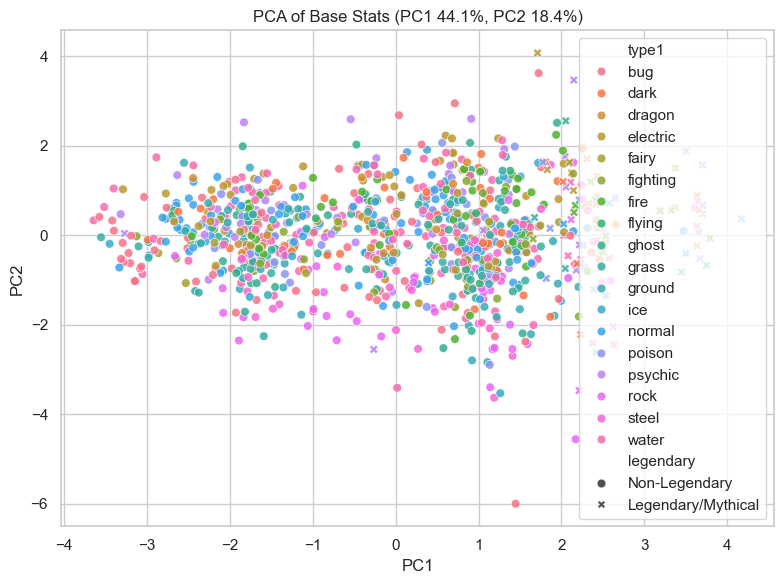

In [77]:
# PCA on base stats: 2D projection colored by type and shaped by legendary
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

base_cols = ["hp","atk","def","spatk","spdef","speed"]
X = df_clean[base_cols].astype(float).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained: PC1 {var_exp[0]:.1f}%, PC2 {var_exp[1]:.1f}%, Total {var_exp.sum():.1f}%")

# Component loadings (which stats drive each PC)
components = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=base_cols)
print("\nPC loadings (which stats drive each component):")
print("PC1 loadings:", components['PC1'].round(2).to_dict())
print("PC2 loadings:", components['PC2'].round(2).to_dict())

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['type1'] = df_clean['type1'].values
pca_df['legendary'] = np.where(df_clean['is_legendary'], 'Legendary/Mythical', 'Non-Legendary')

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2', hue='type1', style='legendary', alpha=0.85, s=40
)
plt.title(f"PCA of Base Stats (PC1 {var_exp[0]:.1f}%, PC2 {var_exp[1]:.1f}%)")
plt.tight_layout()
savefig('pca_base_stats.png')
plt.show()


Role counts:


,count
role_tag,
balanced,802
wall,122
sweeper,56
attacker,32
tank,13


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/role_tag_counts.png


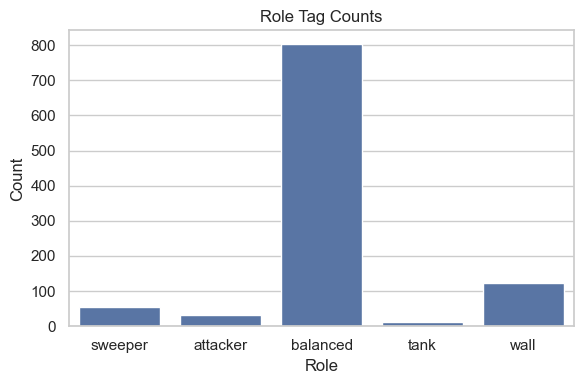

/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/1263840132.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('role_tag')


,role_tag,name,total
492,sweeper,arceus,720
889,sweeper,eternatus,690
383,wall,rayquaza,680
643,wall,zekrom,680
486,wall,giratina,680
483,sweeper,palkia,680
634,balanced,hydreigon,600
997,balanced,baxcalibur,600
648,balanced,genesect,600
894,attacker,regidrago,580


In [78]:
# Role tag counts and top examples per role
import matplotlib.pyplot as plt
import seaborn as sns

role_counts = df_clean['role_tag'].value_counts().sort_values(ascending=False)
print("Role counts:")
display(role_counts.to_frame('count'))

plt.figure(figsize=(6,4))
sns.barplot(x=role_counts.index, y=role_counts.values, color='C0')
plt.title('Role Tag Counts')
plt.xlabel('Role')
plt.ylabel('Count')
plt.tight_layout()
savefig('role_tag_counts.png')
plt.show()

# Show top example names per role (by total)
role_examples = (
    df_clean.sort_values('total', ascending=False)
    .groupby('role_tag')
    .head(3)[['role_tag','name','total']]
)
display(role_examples)


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/atk_speed_scatter.png


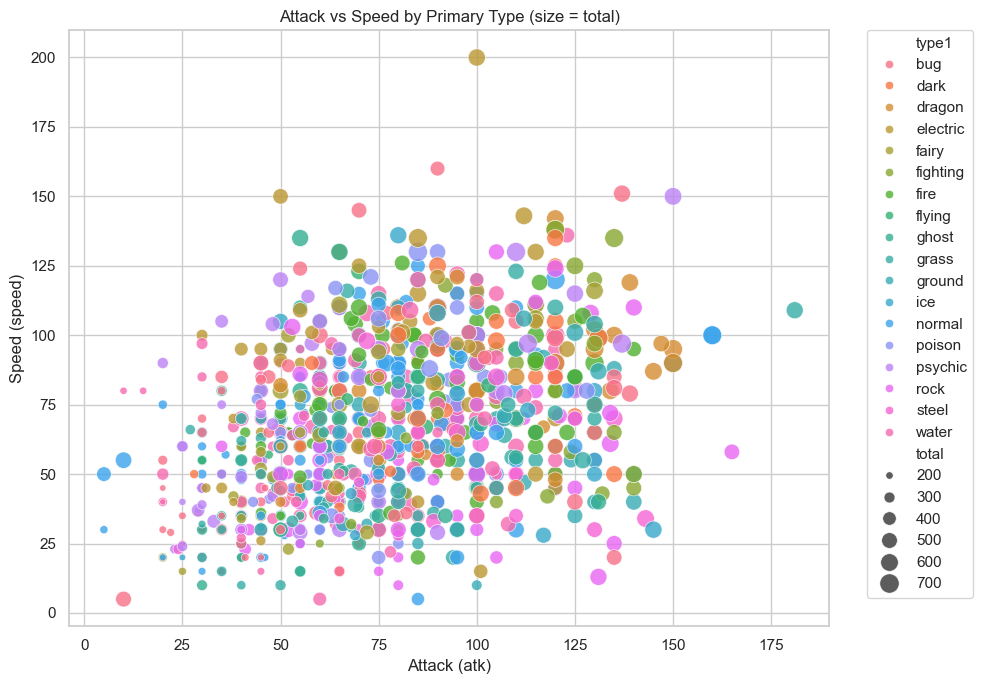

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/correlation_heatmap.png


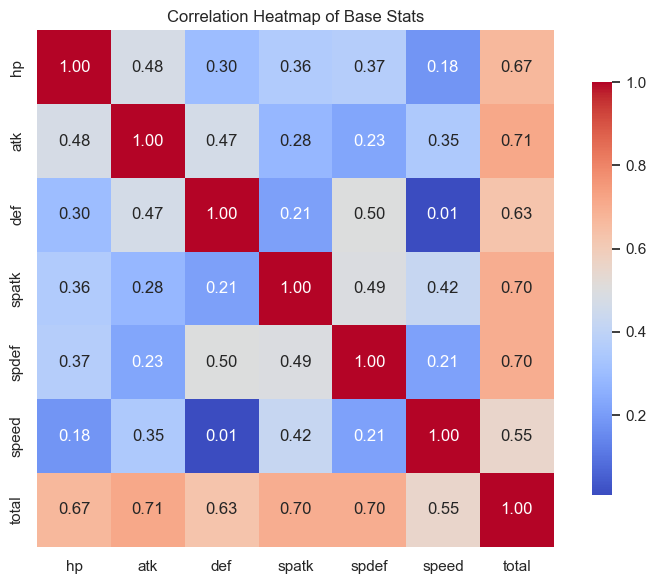

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/legendary_box_total.png


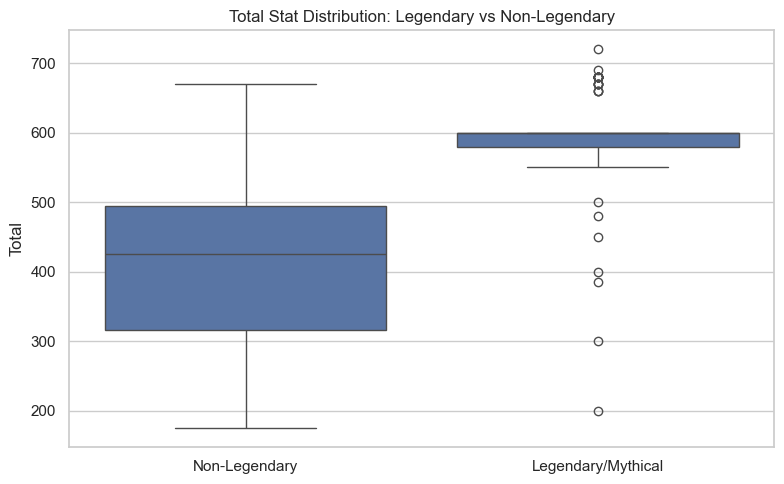

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/generation_counts.png


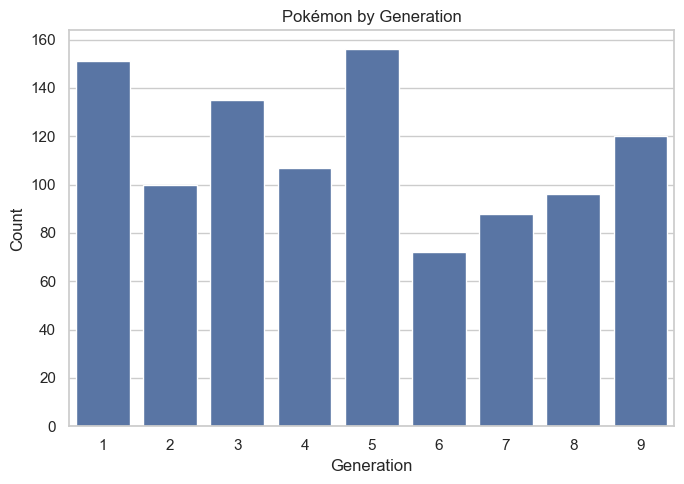

In [79]:
# Save core visuals to output/
# Scatter (Attack vs Speed)
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=df_clean,
    x='atk', y='speed', hue='type1', size='total', sizes=(20, 200),
    alpha=0.8, edgecolor='w', linewidth=0.5
)
plt.title("Attack vs Speed by Primary Type (size = total)")
plt.xlabel("Attack (atk)")
plt.ylabel("Speed (speed)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
savefig('atk_speed_scatter.png')
plt.show()

# Correlation heatmap
num_cols = ["hp", "atk", "def", "spatk", "spdef", "speed", "total"]
corr = df_clean[num_cols].corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Base Stats")
plt.tight_layout()
savefig('correlation_heatmap.png')
plt.show()

# Legendary vs Non-Legendary boxplot
plt.figure(figsize=(8,5))
plot_df = df_clean.assign(group=np.where(df_clean['is_legendary'], 'Legendary/Mythical', 'Non-Legendary'))
plot_order = ['Non-Legendary', 'Legendary/Mythical']
sns.boxplot(data=plot_df, x='group', y='total', order=plot_order)
plt.title("Total Stat Distribution: Legendary vs Non-Legendary")
plt.xlabel("")
plt.ylabel("Total")
plt.tight_layout()
savefig('legendary_box_total.png')
plt.show()

# Generation/type counts rendered and saved
# Generation counts bar
gen_counts = df_clean['generation_num'].value_counts().sort_index()
plt.figure(figsize=(7,5))
sns.barplot(x=gen_counts.index.astype("int"), y=gen_counts.values, color='C0')
plt.title("Pokémon by Generation")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.tight_layout()
savefig('generation_counts.png')
plt.show()


In [80]:
# Export engineered dataset to CSV in output/
engineered_cols = [
    'offense_index','defense_index','speed_to_power','era_total_z',
    'bmi_like','bulk_index','offense_bias','role_tag','generation_num'
]
export_cols = ['id','name','rank','generation','type1','type2','total','hp','atk','def','spatk','spdef','speed'] + engineered_cols

export_df = df_clean[export_cols].copy()
export_path = OUTPUT_DIR / 'pokemon_engineered.csv'
export_df.to_csv(export_path, index=False)
print(f"Exported engineered dataset -> {export_path}")


Exported engineered dataset -> /Users/wesgr/Projects/School/AML/pokemon/output/pokemon_engineered.csv


## Dataset B: ingestion and alignment
We load a complementary dataset (`rounakbanik/pokemon`), inspect schema, and engineer fields to align with Dataset A (naming, totals, indices). This enables cross-dataset comparisons for RQs.


In [81]:
# Dataset 2: Download and locate files (rounakbanik/pokemon)
import kagglehub
from pathlib import Path

path2 = kagglehub.dataset_download("rounakbanik/pokemon")
path2 = Path(path2)
print("Dataset2 path:", path2)

files2 = sorted([p for p in path2.rglob("*") if p.is_file()])
for p in files2[:10]:
    print("-", p.relative_to(path2))

# Heuristic: pick a CSV that looks like the main table
candidates = [p for p in files2 if p.suffix.lower() == ".csv" and "pokemon" in p.name.lower()]
if not candidates:
    candidates = [p for p in files2 if p.suffix.lower() == ".csv"]

if not candidates:
    raise FileNotFoundError("No CSV files found in rounakbanik/pokemon dataset.")

d2_file = candidates[0]
print("Selected file:", d2_file.name)


Dataset2 path: /Users/wesgr/.cache/kagglehub/datasets/rounakbanik/pokemon/versions/1
- pokemon.csv
Selected file: pokemon.csv


In [82]:
# Load Dataset 2 and initial schema view
import pandas as pd

df2 = pd.read_csv(d2_file)
print("Shape:", df2.shape)
print("Columns:", list(df2.columns))

display(df2.head())

print("\nMissing (non-zero):")
na2 = df2.isna().sum()
display(na2[na2>0].sort_values(ascending=False))


Shape: (801, 41)
Columns: ['abilities', 'against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate', 'classfication', 'defense', 'experience_growth', 'height_m', 'hp', 'japanese_name', 'name', 'percentage_male', 'pokedex_number', 'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg', 'generation', 'is_legendary']


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0



Missing (non-zero):


type2              384
percentage_male     98
height_m            20
weight_kg           20
dtype: int64

In [83]:
# Clean and engineer Dataset 2 to align fields
import numpy as np

# Standardize key names to snake_case similar to df_clean
rename_map = {
    'pokedex_number': 'id',
    'attack': 'atk',
    'defense': 'def',
    'sp_attack': 'spatk',
    'sp_defense': 'spdef',
    'height_m': 'height_m',
    'weight_kg': 'weight_kg',
}
df2_clean = df2.rename(columns=rename_map).copy()

# Ensure legendary boolean
if 'is_legendary' in df2_clean.columns:
    df2_clean['is_legendary'] = df2_clean['is_legendary'].astype(bool)
else:
    df2_clean['is_legendary'] = False

# Create total if missing
if 'total' not in df2_clean.columns:
    needed = ['hp','atk','def','spatk','spdef','speed']
    if all(c in df2_clean.columns for c in needed):
        df2_clean['total'] = df2_clean[needed].sum(axis=1)

# Primary/secondary types: ensure category dtype
for col in ['type1','type2','generation']:
    if col in df2_clean.columns:
        df2_clean[col] = df2_clean[col].astype('category')

# Height/weight: prefer metric columns height_m / weight_kg if present
if 'height_m' in df2_clean.columns and 'weight_kg' in df2_clean.columns:
    df2_clean['bmi_like'] = df2_clean['weight_kg'] / (df2_clean['height_m'].replace(0, np.nan) ** 2)

# Reuse engineered indices
if {'atk','spatk'}.issubset(df2_clean.columns):
    df2_clean['offense_index'] = (df2_clean['atk'] + df2_clean['spatk']) / 2
if {'def','spdef'}.issubset(df2_clean.columns):
    df2_clean['defense_index'] = (df2_clean['def'] + df2_clean['spdef']) / 2
if {'speed','total'}.issubset(df2_clean.columns):
    df2_clean['speed_to_power'] = df2_clean['speed'] / df2_clean['total']

print("df2_clean ready. Columns:")
print(sorted(df2_clean.columns))

display(df2_clean.head())


df2_clean ready. Columns:
['abilities', 'against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'atk', 'base_egg_steps', 'base_happiness', 'base_total', 'bmi_like', 'capture_rate', 'classfication', 'def', 'defense_index', 'experience_growth', 'generation', 'height_m', 'hp', 'id', 'is_legendary', 'japanese_name', 'name', 'offense_index', 'percentage_male', 'spatk', 'spdef', 'speed', 'speed_to_power', 'total', 'type1', 'type2', 'weight_kg']


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,type1,type2,weight_kg,generation,is_legendary,total,bmi_like,offense_index,defense_index,speed_to_power
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,grass,poison,6.9,1,False,318,14.081633,57.0,57.0,0.141509
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,grass,poison,13.0,1,False,405,13.000000,71.0,71.5,0.148148
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,grass,poison,100.0,1,False,625,25.000000,111.0,121.5,0.128000
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,fire,NaN,8.5,1,False,309,23.611111,56.0,46.5,0.210356
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,fire,NaN,19.0,1,False,405,15.702479,72.0,61.5,0.197531


## Research questions, modeling, and summaries
This section covers RQ-driven analyses (size vs stats, experience growth and egg steps, type strength and legendary share), a greedy "dream team" heuristic, baseline legendary classifiers, and consolidated summaries. Figures are saved to `output/` for the paper and slides.


Height/Weight vs Base Stats Analysis:

height_m correlations with base stats:
  hp: r=0.478
  atk: r=0.423
  def: r=0.362
  spatk: r=0.353
  spdef: r=0.328
  speed: r=0.202
  total: r=0.535
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/height_m_vs_base_stats.png


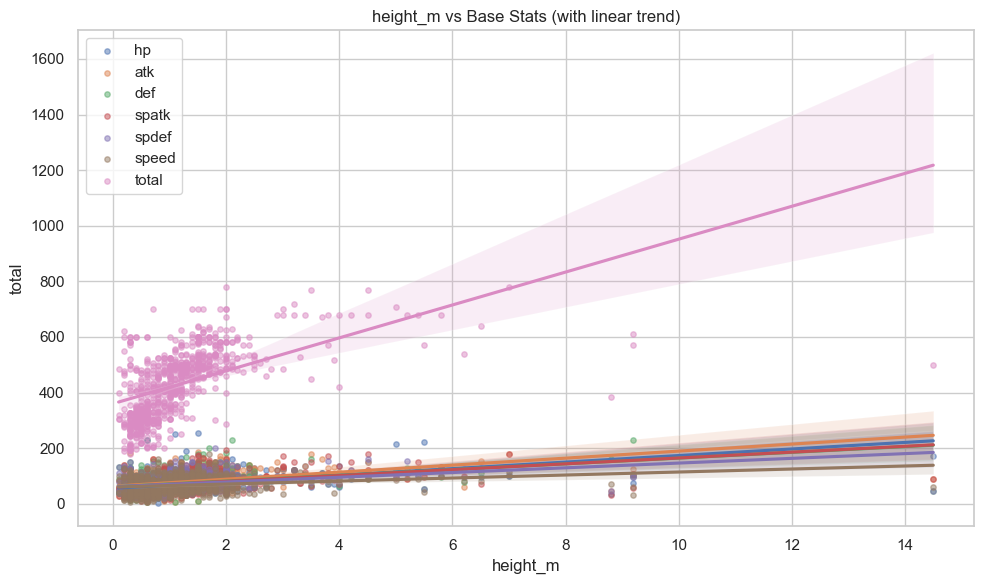


weight_kg correlations with base stats:
  hp: r=0.428
  atk: r=0.382
  def: r=0.424
  spatk: r=0.245
  spdef: r=0.307
  speed: r=0.051
  total: r=0.458
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/weight_kg_vs_base_stats.png


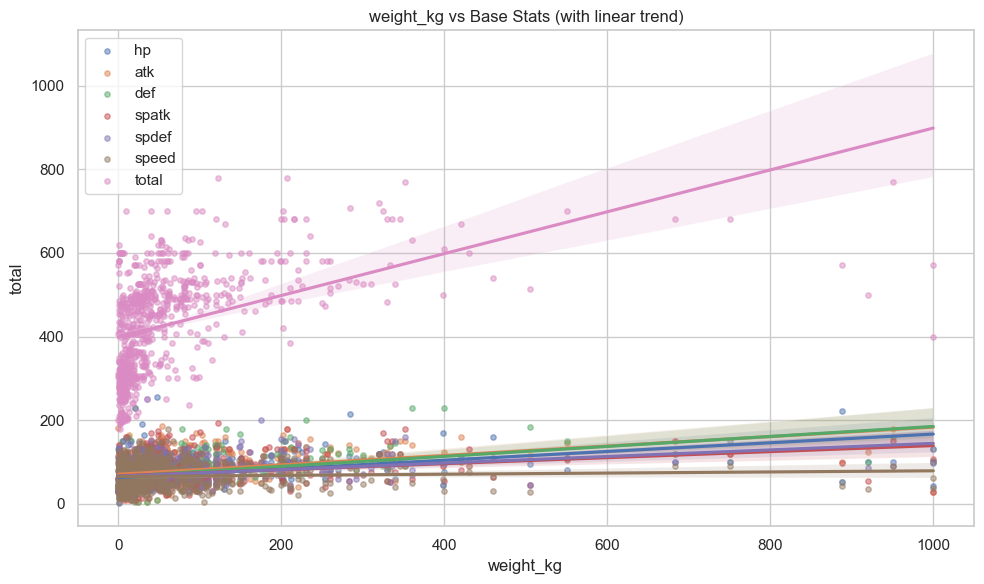


Strongest height/weight correlations (|r| >= 0.3):
height_m vs hp: r=0.478
height_m vs atk: r=0.423
height_m vs def: r=0.362
height_m vs spatk: r=0.353
height_m vs spdef: r=0.328
height_m vs total: r=0.535
weight_kg vs hp: r=0.428
weight_kg vs atk: r=0.382
weight_kg vs def: r=0.424
weight_kg vs spdef: r=0.307
weight_kg vs total: r=0.458
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/height_weight_corr_heatmap.png


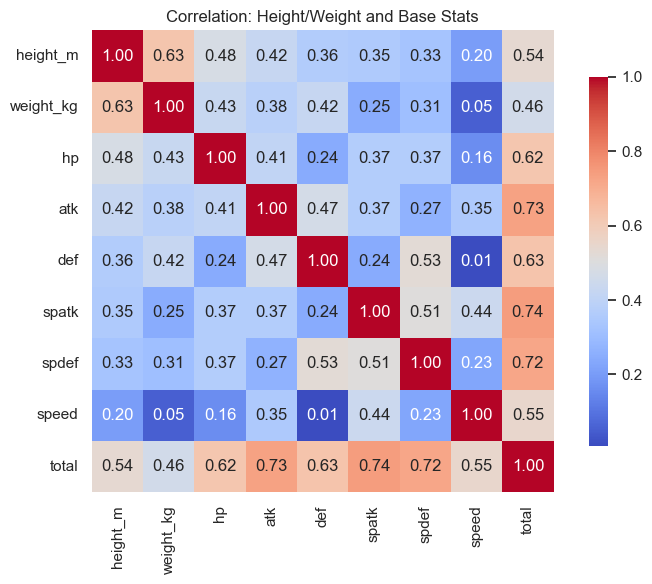

In [84]:
# RQ2: Height and Weight vs Base Stats
import seaborn as sns
import matplotlib.pyplot as plt

cols_hw = [c for c in ['height_m','weight_kg'] if c in df2_clean.columns]
base_cols = [c for c in ['hp','atk','def','spatk','spdef','speed','total'] if c in df2_clean.columns]

print("Height/Weight vs Base Stats Analysis:")

for feature in cols_hw:
    print(f"\n{feature} correlations with base stats:")
    for stat in base_cols:
        r = df2_clean[feature].corr(df2_clean[stat])
        print(f"  {stat}: r={r:.3f}")
    
    plt.figure(figsize=(10,6))
    for stat in base_cols:
        sns.regplot(data=df2_clean, x=feature, y=stat, scatter_kws={'s':15, 'alpha':0.5}, label=stat)
    plt.title(f"{feature} vs Base Stats (with linear trend)")
    plt.legend()
    plt.tight_layout()
    savefig(f'{feature}_vs_base_stats.png')
    plt.show()

# Pairwise correlations heatmap including height/weight
import numpy as np
num_for_corr = [c for c in ['height_m','weight_kg'] + base_cols if c in df2_clean.columns]
corr2 = df2_clean[num_for_corr].corr()

print("\nStrongest height/weight correlations (|r| >= 0.3):")
for i, col1 in enumerate(['height_m','weight_kg']):
    if col1 in corr2.columns:
        for j, col2 in enumerate(base_cols):
            if col2 in corr2.columns:
                r = corr2.loc[col1, col2]
                if abs(r) >= 0.3:
                    print(f"{col1} vs {col2}: r={r:.3f}")

plt.figure(figsize=(8,6))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink':0.8})
plt.title('Correlation: Height/Weight and Base Stats')
plt.tight_layout()
savefig('height_weight_corr_heatmap.png')
plt.show()


Available columns: ['experience_growth', 'base_egg_steps', 'base_happiness', 'capture_rate']
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_hp.png


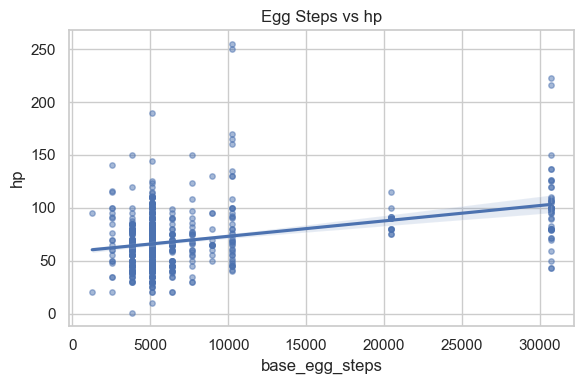

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_atk.png


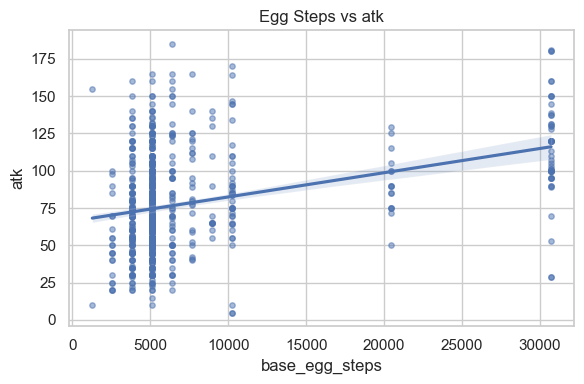

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_def.png


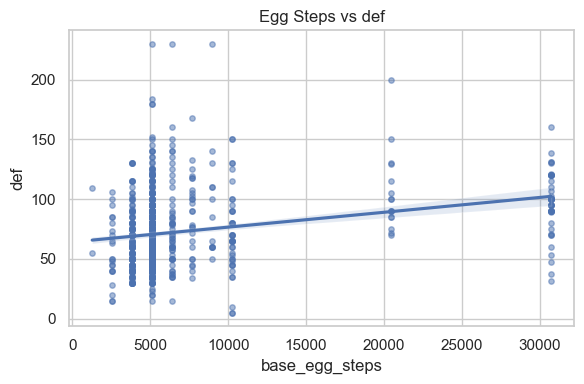

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_spatk.png


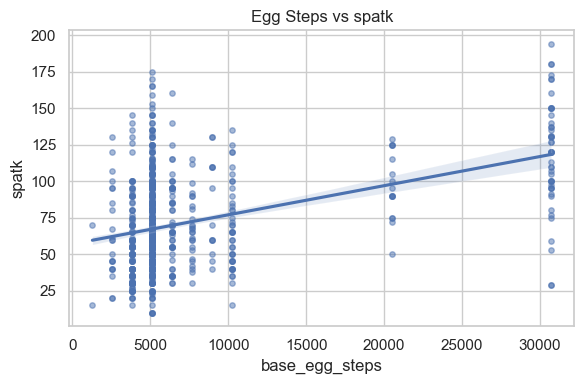

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_spdef.png


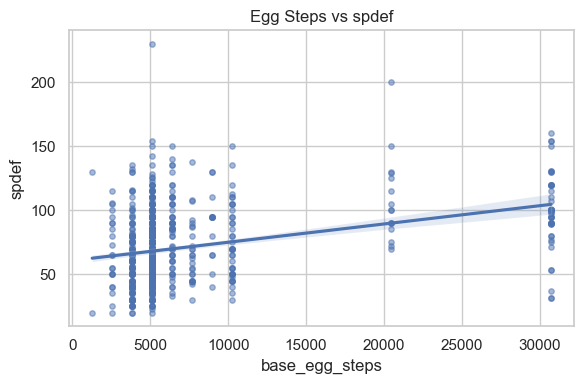

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_speed.png


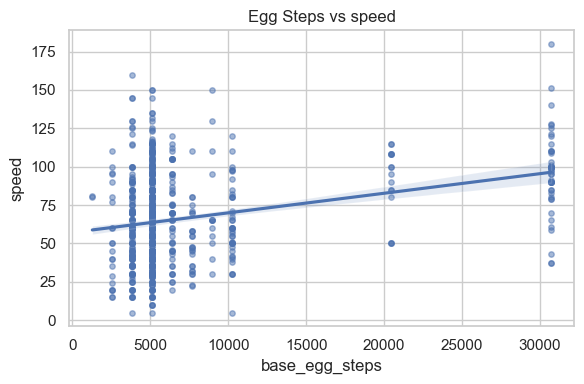

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_vs_total.png


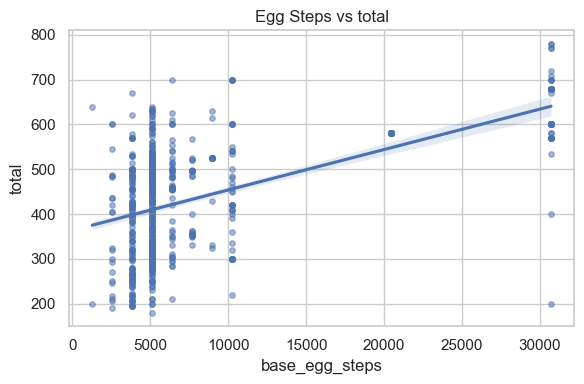

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/eggsteps_experience_corr_heatmap.png


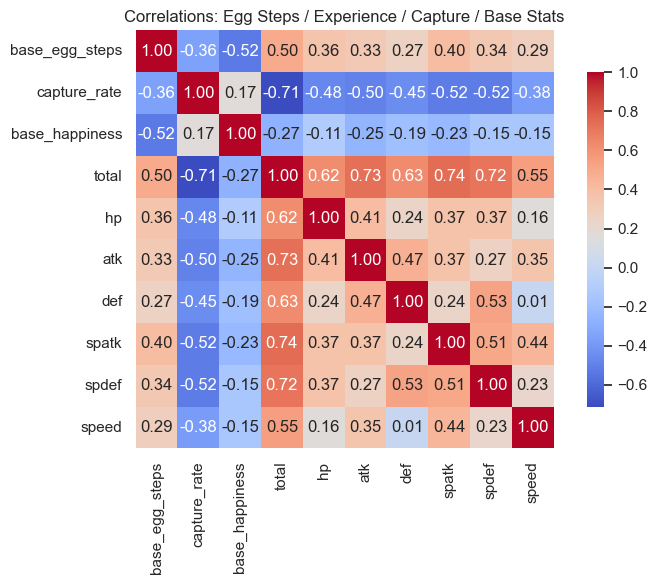

In [85]:
# RQ3: Experience Growth and Egg Steps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

cols = [c for c in ['experience_growth','base_egg_steps','base_happiness','capture_rate'] if c in df2_clean.columns]
print("Available columns:", cols)

# If experience_growth is categorical (e.g., strings like 'Medium Fast'), encode for plotting counts vs stats
if 'experience_growth' in df2_clean.columns and df2_clean['experience_growth'].dtype == object:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df2_clean, x='experience_growth', order=df2_clean['experience_growth'].value_counts().index)
    plt.title('Experience Growth Category Counts')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    savefig('exp_growth_counts.png')
    plt.show()

# Relationship between base_egg_steps and various stats
if 'base_egg_steps' in df2_clean.columns:
    for stat in [c for c in ['hp','atk','def','spatk','spdef','speed','total'] if c in df2_clean.columns]:
        plt.figure(figsize=(6,4))
        sns.regplot(data=df2_clean, x='base_egg_steps', y=stat, scatter_kws={'s':15, 'alpha':0.5})
        plt.title(f'Egg Steps vs {stat}')
        plt.tight_layout()
        savefig(f'eggsteps_vs_{stat}.png')
        plt.show()

# Correlation matrix over numeric subset including egg steps and capture rate
num_cols2 = [c for c in ['base_egg_steps','capture_rate','base_happiness','total','hp','atk','def','spatk','spdef','speed'] if c in df2_clean.columns]
if num_cols2:
    # Build a numeric view with robust coercion for messy strings (e.g., '30 (Meteorite)255 (Core)')
    corr_df = df2_clean[num_cols2].copy()

    def extract_numeric_mean(val):
        tokens = re.findall(r'-?\d+\.?\d*', str(val))
        nums = [float(t) for t in tokens] if tokens else []
        return np.nan if len(nums) == 0 else float(np.mean(nums))

    for col in ['base_egg_steps','capture_rate','base_happiness']:
        if col in corr_df.columns:
            # try direct coercion
            coerced = pd.to_numeric(corr_df[col], errors='coerce')
            # fill remaining NaNs by extracting numeric tokens and averaging
            mask = coerced.isna() & corr_df[col].notna()
            if mask.any():
                coerced.loc[mask] = corr_df.loc[mask, col].apply(extract_numeric_mean)
            corr_df[col] = coerced

    corr3 = corr_df.corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr3, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink':0.8})
    plt.title('Correlations: Egg Steps / Experience / Capture / Base Stats')
    plt.tight_layout()
    savefig('eggsteps_experience_corr_heatmap.png')
    plt.show()


Type Strength Analysis:

Strongest types by mean total:
1. dragon: 522.8
2. steel: 491.6
3. psychic: 461.3
4. flying: 453.3
5. fire: 450.6

Weakest types by mean total:
1. fighting: 414.8
2. grass: 412.6
3. normal: 401.3
4. poison: 399.6
5. bug: 380.4


/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/206411970.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_strength = df2_clean.groupby('type1')['total'].mean().sort_values(ascending=False)


,mean_total
type1,
dragon,522.777778
steel,491.583333
psychic,461.264151
flying,453.333333
fire,450.634615
dark,449.758621
rock,447.266667
electric,436.153846
ghost,434.703704


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/type_strength_mean_total.png


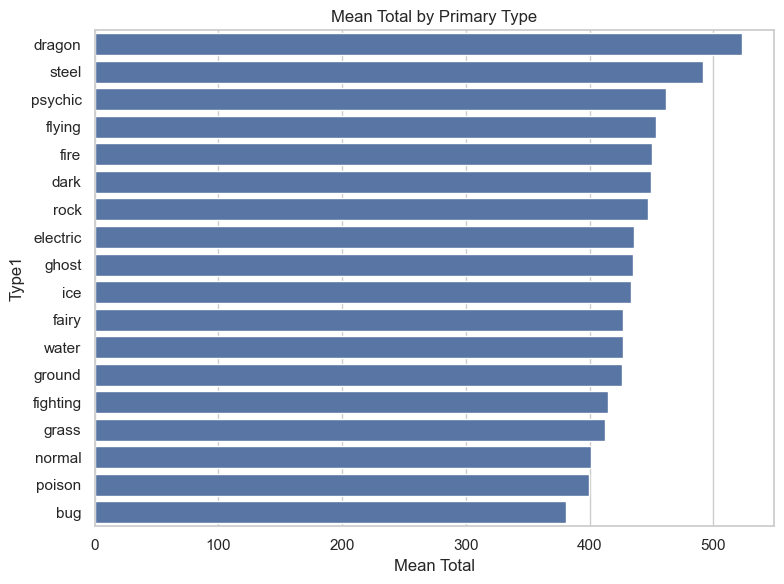


Defensive analysis using 18 type effectiveness columns:
Most resistant types (lowest vulnerability):
1. steel: 0.859
2. electric: 0.955
3. ghost: 0.977
4. fairy: 0.978
5. poison: 0.984
Most vulnerable types:
1. psychic: 1.107
2. bug: 1.114
3. grass: 1.162
4. ice: 1.194
5. rock: 1.196


/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/206411970.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_defense = df2_clean.groupby('type1')['defensive_vuln'].mean().sort_values()


,defensive_vuln
type1,
steel,0.858796
electric,0.955128
ghost,0.977366
fairy,0.978395
poison,0.983507
normal,1.004497
fire,1.013088
water,1.015838
dark,1.075670


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/type_defensive_vulnerability.png


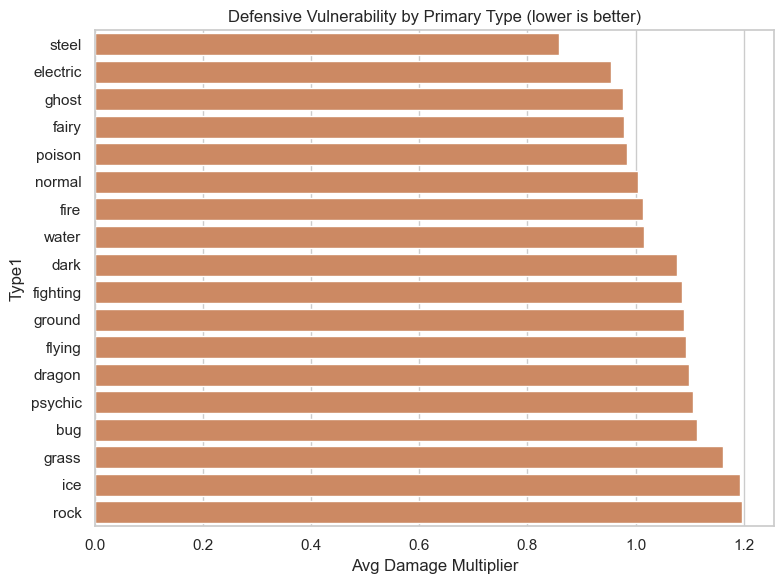


Composite ranking (power + defense):
Top 5 overall strongest types:
1. steel: composite rank 1.5
2. electric: composite rank 5.0
3. ghost: composite rank 6.0
4. fire: composite rank 6.0
5. dragon: composite rank 7.0
Bottom 5 overall weakest types:
1. fighting: composite rank 12.0
2. rock: composite rank 12.5
3. ice: composite rank 13.5
4. grass: composite rank 15.5
5. bug: composite rank 16.5


/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/206411970.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'def_vuln_rank': df2_clean.groupby('type1')['defensive_vuln'].mean().rank(ascending=True)


,mean_total_rank,def_vuln_rank,composite
type1,,,
steel,2.0,1.0,1.5
electric,8.0,2.0,5.0
ghost,9.0,3.0,6.0
fire,5.0,7.0,6.0
dragon,1.0,13.0,7.0


,mean_total_rank,def_vuln_rank,composite
type1,,,
fighting,14.0,10.0,12.0
rock,7.0,18.0,12.5
ice,10.0,17.0,13.5
grass,15.0,16.0,15.5
bug,18.0,15.0,16.5


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/type_composite_strength.png


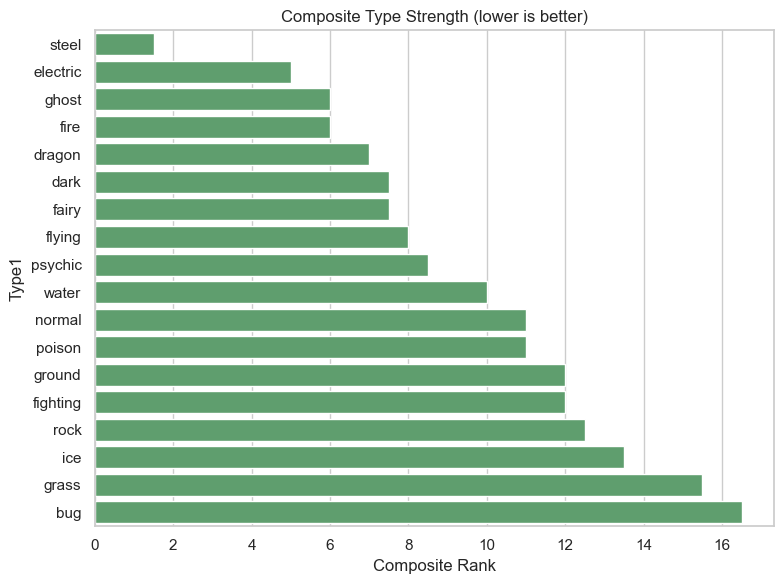

In [86]:
# RQ4: Strongest and weakest types
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Type Strength Analysis:")

# Define a simple strength metric per type: mean total and win-rate proxy
# If against_* columns exist, we can summarize their effectiveness
against_cols = [c for c in df2_clean.columns if c.startswith('against_')]

# Mean total by primary type
type_strength = df2_clean.groupby('type1')['total'].mean().sort_values(ascending=False)
print("\nStrongest types by mean total:")
for i, (type_name, mean_total) in enumerate(type_strength.head(5).items()):
    print(f"{i+1}. {type_name}: {mean_total:.1f}")

print("\nWeakest types by mean total:")
for i, (type_name, mean_total) in enumerate(type_strength.tail(5).items()):
    print(f"{i+1}. {type_name}: {mean_total:.1f}")

display(type_strength.to_frame('mean_total'))

plt.figure(figsize=(8,6))
sns.barplot(y=type_strength.index, x=type_strength.values, order=list(type_strength.index), color='C0')
plt.title('Mean Total by Primary Type')
plt.xlabel('Mean Total')
plt.ylabel('Type1')
plt.tight_layout()
savefig('type_strength_mean_total.png')
plt.show()

# If effectiveness columns are available, compute overall defensive vulnerability (lower is better)
if against_cols:
    print(f"\nDefensive analysis using {len(against_cols)} type effectiveness columns:")
    # Defensive score: mean damage multiplier received across all attack types
    df2_clean['defensive_vuln'] = df2_clean[against_cols].mean(axis=1)
    type_defense = df2_clean.groupby('type1')['defensive_vuln'].mean().sort_values()
    
    print("Most resistant types (lowest vulnerability):")
    for i, (type_name, vuln) in enumerate(type_defense.head(5).items()):
        print(f"{i+1}. {type_name}: {vuln:.3f}")
    
    print("Most vulnerable types:")
    for i, (type_name, vuln) in enumerate(type_defense.tail(5).items()):
        print(f"{i+1}. {type_name}: {vuln:.3f}")
    
    display(type_defense.to_frame('defensive_vuln'))

    plt.figure(figsize=(8,6))
    sns.barplot(y=type_defense.index, x=type_defense.values, order=list(type_defense.index), color='C1')
    plt.title('Defensive Vulnerability by Primary Type (lower is better)')
    plt.xlabel('Avg Damage Multiplier')
    plt.ylabel('Type1')
    plt.tight_layout()
    savefig('type_defensive_vulnerability.png')
    plt.show()

# Combine ranks if both available
if against_cols:
    combined = (
        pd.DataFrame({
            'mean_total_rank': type_strength.rank(ascending=False),
            'def_vuln_rank': df2_clean.groupby('type1')['defensive_vuln'].mean().rank(ascending=True)
        })
        .dropna()
    )
    combined['composite'] = combined[['mean_total_rank','def_vuln_rank']].mean(axis=1)
    combined = combined.sort_values('composite')
    
    print("\nComposite ranking (power + defense):")
    print("Top 5 overall strongest types:")
    for i, (type_name, rank) in enumerate(combined.head(5)['composite'].items()):
        print(f"{i+1}. {type_name}: composite rank {rank:.1f}")
    
    print("Bottom 5 overall weakest types:")
    for i, (type_name, rank) in enumerate(combined.tail(5)['composite'].items()):
        print(f"{i+1}. {type_name}: composite rank {rank:.1f}")
    
    display(combined.head(5))
    display(combined.tail(5))

    plt.figure(figsize=(8,6))
    sns.barplot(y=combined.index, x=combined['composite'], order=list(combined.index), color='C2')
    plt.title('Composite Type Strength (lower is better)')
    plt.xlabel('Composite Rank')
    plt.ylabel('Type1')
    plt.tight_layout()
    savefig('type_composite_strength.png')
    plt.show()


Legendary Probability by Type Analysis:

Types most likely to be legendary:
1. flying: 33.3% (1/3)
2. psychic: 32.1% (17/53)
3. dragon: 25.9% (7/27)
4. steel: 25.0% (6/24)
5. electric: 12.8% (5/39)

Types least likely to be legendary:
1. bug: 4.2% (3/72)
2. ghost: 3.7% (1/27)
3. normal: 2.9% (3/105)
4. poison: 0.0% (0/32)
5. fighting: 0.0% (0/28)

Overall legendary rate: 8.7%


/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/1302615680.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2_clean.groupby('type1')['is_legendary']


,legendary_%
type1,
flying,33.3
psychic,32.1
dragon,25.9
steel,25.0
electric,12.8
dark,10.3
fire,9.6
rock,8.9
ice,8.7


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/legendary_share_by_type.png


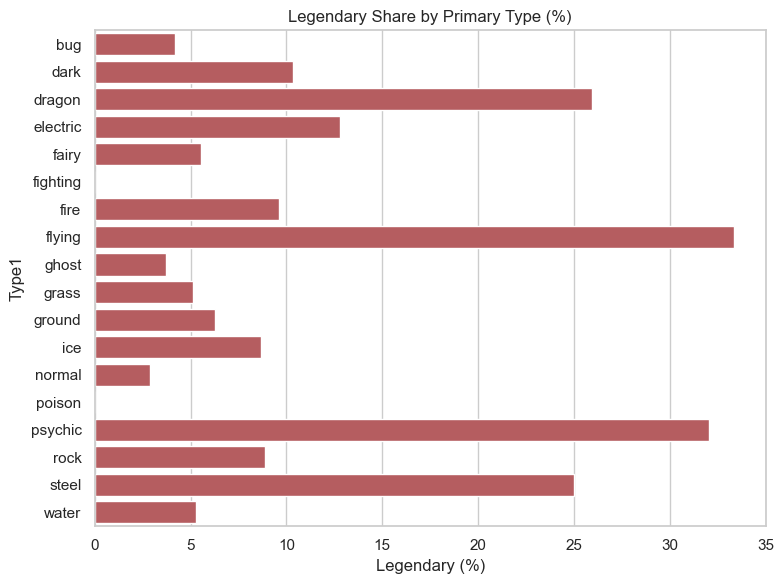

In [ ]:
# RQ5: Which type is most likely legendary?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Legendary Probability by Type Analysis:")

legendary_rate = (
    df2_clean.groupby('type1')['is_legendary']
    .mean()
    .sort_values(ascending=False)
)

# Get sample sizes per type
type_counts = df2_clean['type1'].value_counts()
legendary_counts = df2_clean[df2_clean['is_legendary']]['type1'].value_counts()

print("\nTypes most likely to be legendary:")
for i, (type_name, rate) in enumerate(legendary_rate.head(5).items()):
    n_total = type_counts.get(type_name, 0)
    n_legendary = legendary_counts.get(type_name, 0)
    print(f"{i+1}. {type_name}: {rate*100:.1f}% ({n_legendary}/{n_total})")

print("\nTypes least likely to be legendary:")
for i, (type_name, rate) in enumerate(legendary_rate.tail(5).items()):
    n_total = type_counts.get(type_name, 0)
    n_legendary = legendary_counts.get(type_name, 0)
    print(f"{i+1}. {type_name}: {rate*100:.1f}% ({n_legendary}/{n_total})")

overall_legendary_rate = df2_clean['is_legendary'].mean()
print(f"\nOverall legendary rate: {overall_legendary_rate*100:.1f}%")

display((legendary_rate*100).round(1).to_frame('legendary_%'))

plt.figure(figsize=(8,6))
sns.barplot(y=legendary_rate.index, x=legendary_rate.values*100, order=list(legendary_rate.index), color='C3')
plt.title('Legendary Share by Primary Type (%)')
plt.xlabel('Legendary (%)')
plt.ylabel('Type1')
plt.tight_layout()
savefig('legendary_share_by_type.png')
plt.show()


Dream Team Construction:
Scoring formula: total + 0.5*offense_index + 0.3*speed
Constraint: diverse primary types (no duplicates)

Greedy selection process:
Pick 1: Mewtwo (psychic) - Score: 908.0
Pick 2: Rayquaza (dragon) - Score: 904.5
Pick 3: Groudon (ground) - Score: 879.5
Pick 4: Kyogre (water) - Score: 879.5
Pick 5: Arceus (normal) - Score: 816.0
Pick 6: Diancie (rock) - Score: 813.0

Final Dream Team Summary:
Average total: 753.3
Average offense: 160.3
Average defense: 112.5
Average speed: 110.8
Type diversity: 6/6 unique primary types


,name,type1,type2,hp,atk,def,spatk,spdef,speed,total,offense_index,defense_index,score
149,Mewtwo,psychic,NaN,106,150,70,194,120,140,780,172.0,95.0,908.0
383,Rayquaza,dragon,flying,105,180,100,180,100,115,780,180.0,100.0,904.5
382,Groudon,ground,NaN,100,180,160,150,90,90,770,165.0,125.0,879.5
381,Kyogre,water,NaN,100,150,90,180,160,90,770,165.0,125.0,879.5
492,Arceus,normal,NaN,120,120,120,120,120,120,720,120.0,120.0,816.0
718,Diancie,rock,fairy,50,160,110,160,110,110,700,160.0,110.0,813.0


Saved dream team -> /Users/wesgr/Projects/School/AML/pokemon/output/dream_team.csv
Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/dream_team_radars.png


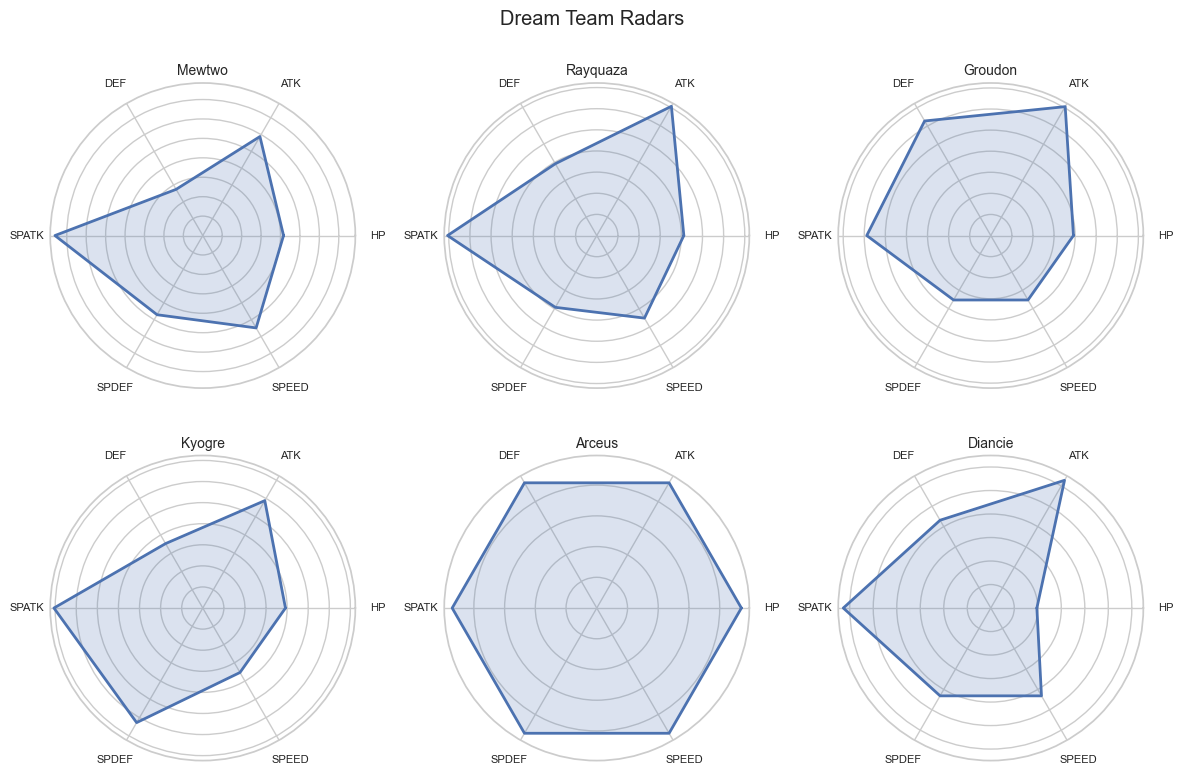

In [88]:
# RQ6: Dream team heuristic (greedy by offense/coverage, avoid duplicate primary types)
import numpy as np
import pandas as pd

print("Dream Team Construction:")
print("Scoring formula: total + 0.5*offense_index + 0.3*speed")
print("Constraint: diverse primary types (no duplicates)")

# Use total as overall power, but bias toward offense_index and speed
score = (
    df2_clean['total']
    + 0.5 * df2_clean.get('offense_index', 0)
    + 0.3 * df2_clean.get('speed', 0)
)

pool = df2_clean.assign(score=score).copy()

team = []
used_types = set()
print("\nGreedy selection process:")

for i in range(6):
    candidates = pool[~pool['type1'].isin(used_types)].sort_values('score', ascending=False)
    if candidates.empty:
        candidates = pool.sort_values('score', ascending=False)
    pick = candidates.iloc[0]
    team.append(pick)
    used_types.add(pick['type1'])
    pool = pool.drop(pick.name)
    print(f"Pick {i+1}: {pick['name']} ({pick['type1']}) - Score: {pick['score']:.1f}")

team_df = pd.DataFrame(team)
team_df = team_df[['name','type1','type2','hp','atk','def','spatk','spdef','speed','total','offense_index','defense_index','score']]

print("\nFinal Dream Team Summary:")
print(f"Average total: {team_df['total'].mean():.1f}")
print(f"Average offense: {team_df['offense_index'].mean():.1f}")
print(f"Average defense: {team_df['defense_index'].mean():.1f}")
print(f"Average speed: {team_df['speed'].mean():.1f}")
print(f"Type diversity: {len(team_df['type1'].unique())}/6 unique primary types")

display(team_df)

# Save team to CSV
team_path = OUTPUT_DIR / 'dream_team.csv'
team_df.to_csv(team_path, index=False)
print(f"Saved dream team -> {team_path}")

# Plot team radar per Pokémon (optional small multiples)
import matplotlib.pyplot as plt
stats_axes = ["hp", "atk", "def", "spatk", "spdef", "speed"]

fig, axes = plt.subplots(2, 3, subplot_kw={'projection':'polar'}, figsize=(12,8))
axes = axes.ravel()

angles = np.linspace(0, 2 * np.pi, len(stats_axes), endpoint=False)
angles = np.concatenate([angles, angles[:1]])
radial_max = 255.0

for ax, (_, row) in zip(axes, team_df.iterrows()):
    values = row[stats_axes].values.astype(float)
    values = np.concatenate([values, values[:1]]) / radial_max
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks(np.linspace(0, 2*np.pi, len(stats_axes), endpoint=False))
    ax.set_xticklabels([s.upper() for s in stats_axes], fontsize=8)
    ax.set_yticklabels([])
    ax.set_title(row['name'], fontsize=10)

plt.suptitle('Dream Team Radars')
plt.tight_layout()
savefig('dream_team_radars.png')
plt.show()


In [89]:
# Summary: Dataset A core stats and cohorts
import numpy as np

print("Dataset A — Overall:")
print("Total Pokémon:", len(df_clean))
print("Legendary/Mythical count:", int(df_clean['is_legendary'].sum()))
print("Non-legendary count:", int((~df_clean['is_legendary']).sum()))

# Generation means and top/bottom generations by total
gen_summary = df_clean.groupby('generation_num')['total'].agg(['count','mean','std']).round(2)
print("\nMean total by generation:")
print(gen_summary)

# Legendary vs Non stats
cohort_summary = (
    df_clean.assign(group=np.where(df_clean['is_legendary'], 'Legendary/Mythical', 'Non-Legendary'))
    .groupby('group')[['hp','atk','def','spatk','spdef','speed','total']]
    .mean()
    .round(1)
)
print("\nCohort means (Legendary vs Non):")
print(cohort_summary)

# Strongest and weakest types by total mean
type_means = df_clean.groupby('type1')['total'].mean().sort_values(ascending=False)
print("\nTop 5 primary types by mean total:")
print(type_means.head(5).round(1))
print("\nBottom 5 primary types by mean total:")
print(type_means.tail(5).round(1))


Dataset A — Overall:
Total Pokémon: 1025
Legendary/Mythical count: 93
Non-legendary count: 932

Mean total by generation:
                count    mean     std
generation_num                       
1                 151  407.64   99.88
2                 100  407.18  112.46
3                 135  403.73  115.57
4                 107  445.57  117.25
5                 156  425.76  102.47
6                  72  429.31  111.73
7                  88  449.41  119.15
8                  96  439.22  116.30
9                 120  457.39  116.61

Cohort means (Legendary vs Non):
                      hp    atk   def  spatk  spdef  speed  total
group                                                            
Legendary/Mythical  93.5  103.2  97.7  103.5   99.4   95.2  592.6
Non-Legendary       67.9   75.0  70.0   66.7   67.3   64.4  411.2

Top 5 primary types by mean total:
type1
dragon     490.2
steel      475.1
dark       454.7
psychic    446.7
fire       446.2
Name: total, dtype: float64

Bottom

/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/4175761679.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_means = df_clean.groupby('type1')['total'].mean().sort_values(ascending=False)


In [90]:
# Summary: Dataset B — type strength and legendary share
import pandas as pd

# Type strength
type_mean_total = df2_clean.groupby('type1')['total'].mean().sort_values(ascending=False).round(1)
print("Mean total by primary type (top 5):")
print(type_mean_total.head(5))
print("\nMean total by primary type (bottom 5):")
print(type_mean_total.tail(5))

# Legendary share
type_legendary = (df2_clean.groupby('type1')['is_legendary'].mean()*100).sort_values(ascending=False).round(1)
print("\nLegendary share by primary type (top 5, %):")
print(type_legendary.head(5))
print("\nLegendary share by primary type (bottom 5, %):")
print(type_legendary.tail(5))


Mean total by primary type (top 5):
type1
dragon     522.8
steel      491.6
psychic    461.3
flying     453.3
fire       450.6
Name: total, dtype: float64

Mean total by primary type (bottom 5):
type1
fighting    414.8
grass       412.6
normal      401.3
poison      399.6
bug         380.4
Name: total, dtype: float64

Legendary share by primary type (top 5, %):
type1
flying      33.3
psychic     32.1
dragon      25.9
steel       25.0
electric    12.8
Name: is_legendary, dtype: float64

Legendary share by primary type (bottom 5, %):
type1
bug         4.2
ghost       3.7
normal      2.9
poison      0.0
fighting    0.0
Name: is_legendary, dtype: float64


/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/3701528871.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_mean_total = df2_clean.groupby('type1')['total'].mean().sort_values(ascending=False).round(1)
/var/folders/nc/_bms1pls7tg0kq87prwfp5qc0000gn/T/ipykernel_54630/3701528871.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  type_legendary = (df2_clean.groupby('type1')['is_legendary'].mean()*100).sort_values(ascending=False).round(1)


### Legendary classification (Dataset B)
We train two baseline classifiers to predict `is_legendary` using engineered numeric features and one-hot encoded categories. A scikit-learn pipeline handles imputation and encoding; we fit Logistic Regression and a Random Forest, report concise metrics, and save confusion matrices to `output/` for inclusion in the paper.


/Users/wesgr/Projects/School/AML/pokemon/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/legendary_clf_logit_cm.png


<Figure size 400x400 with 0 Axes>

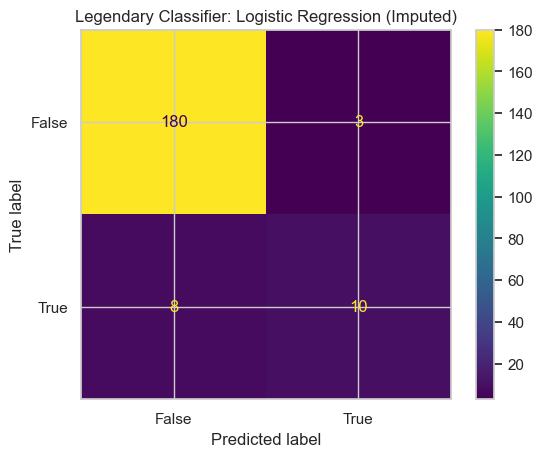

Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/legendary_clf_rf_cm.png


<Figure size 400x400 with 0 Axes>

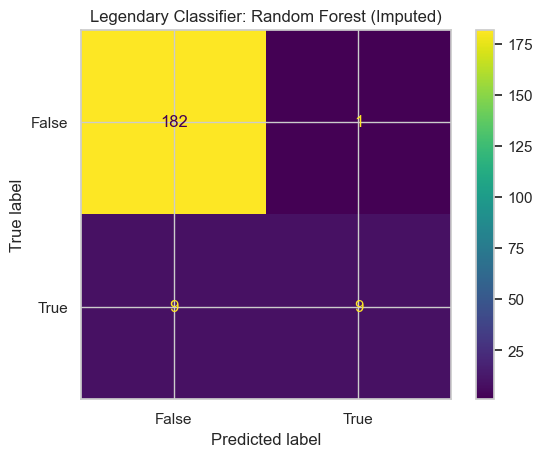

Legendary classifier performance:
LogisticRegression: acc=0.945, precision=0.769, recall=0.556, f1=0.645
RandomForest: acc=0.950, precision=0.900, recall=0.500, f1=0.643


In [91]:
# Legendary classifier performance (self-contained training + evaluation)
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt

# Features and split
features_num = [c for c in ['hp','atk','def','spatk','spdef','speed','total','height_m','weight_kg','bmi_like','offense_index','defense_index','speed_to_power'] if c in df2_clean.columns]
features_cat = [c for c in ['type1','type2','generation'] if c in df2_clean.columns]
X = df2_clean[features_num + features_cat]
y = df2_clean['is_legendary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Preprocess with imputers
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore')),
])

preprocess_imputed = ColumnTransformer([
    ('num', numeric_transformer, features_num),
    ('cat', categorical_transformer, features_cat),
])

# Train Logistic Regression
logit = Pipeline([
    ('prep', preprocess_imputed),
    ('clf', LogisticRegression(max_iter=1000))
])
logit.fit(X_train, y_train)

plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_estimator(logit, X_test, y_test)
plt.title('Legendary Classifier: Logistic Regression (Imputed)')
savefig('legendary_clf_logit_cm.png')
plt.show()

# Train Random Forest
rf = Pipeline([
    ('prep', preprocess_imputed),
    ('clf', RandomForestClassifier(n_estimators=400, random_state=42))
])
rf.fit(X_train, y_train)

plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title('Legendary Classifier: Random Forest (Imputed)')
savefig('legendary_clf_rf_cm.png')
plt.show()

# Print concise metrics
def summarize_model(name, model):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
    print(f"{name}: acc={acc:.3f}, precision={prec:.3f}, recall={rec:.3f}, f1={f1:.3f}")

print("Legendary classifier performance:")
summarize_model("LogisticRegression", logit)
summarize_model("RandomForest", rf)


Saved figure -> /Users/wesgr/Projects/School/AML/pokemon/output/type_by_generation_heatmap.png


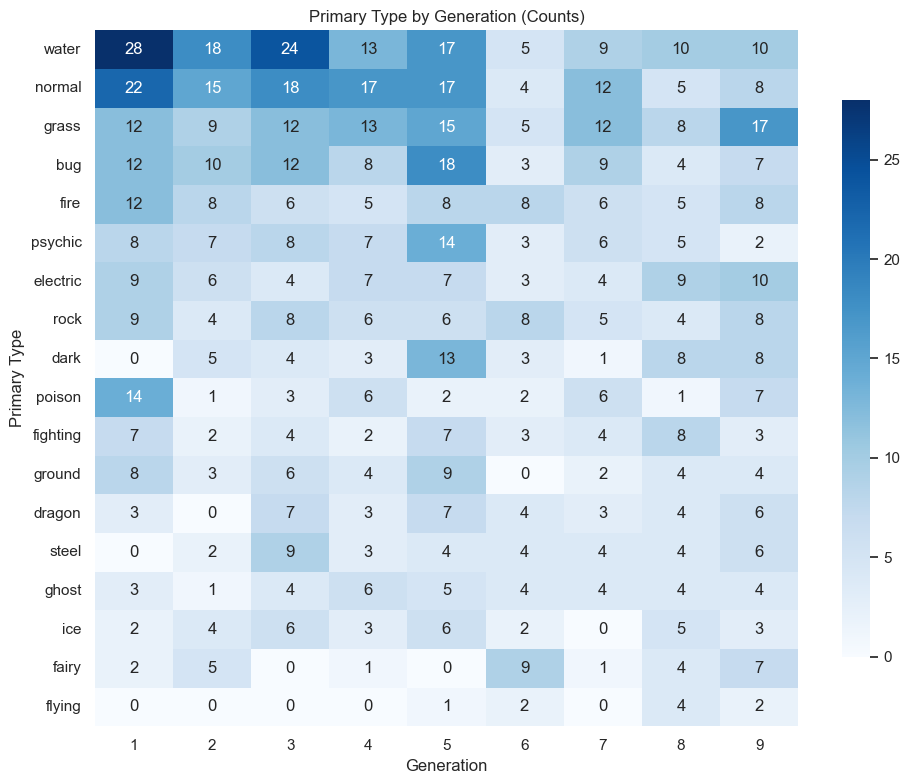

In [92]:
# Heatmap: Primary type by generation (counts)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare crosstab of primary types by generation (drop missing generation/type)
valid = df_clean.dropna(subset=['generation_num', 'type1']).copy()
ct = pd.crosstab(valid['type1'], valid['generation_num'])
# Order types by total frequency and generations ascending
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
ct = ct.reindex(sorted(ct.columns), axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar_kws={'shrink': 0.8})
plt.title('Primary Type by Generation (Counts)')
plt.xlabel('Generation')
plt.ylabel('Primary Type')
plt.tight_layout()
savefig('type_by_generation_heatmap.png')
plt.show()
